In [ ]:
#---
#title: Electricity Price Forecasting in Germany and Luxembourg 
#subtitle: "A Machine Learning Approach""
#author:
#  - name: Ricard Boual, Antonin
##date: "December 2025"

# Packages
___

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.decomposition import PCA
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tools.sm_exceptions import ValueWarning
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import RandomizedSearchCV
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pytz
from tensorflow.keras.optimizers import Adam
from sklearn.multioutput import MultiOutputRegressor
import openmeteo_requests
import requests_cache
from entsoe import EntsoePandasClient
from retry_requests import retry

# Import of day-ahead electricity price data
___
Day-ahead prices were obtained from the ENTSO-E API and upsampled to hourly prices using the mean.
- The API codes are all at the very end in the Appendix

In [3]:
df_prices = pd.read_csv("../Data/ENTSO-E Germany Price Data.csv")
df_prices.rename(columns={"Unnamed: 0":"DateTime", "0":"Price"}, inplace=True)
df_prices["DateTime"] = pd.to_datetime(df_prices["DateTime"], utc=True)
df_prices = df_prices.set_index("DateTime")

### Renaming and converting datatypes

In [4]:
df_before_resampling = df_prices.copy()

df_prices = df_prices.resample('h').mean() # Resamples the data into one hour intervals, since after the MTU change some data is in 15 min intervals

print(df_prices.dtypes)
print(df_prices.tail()) # Check that all the newer observations are now also in hours

Price    float64
dtype: object
                              Price
DateTime                           
2025-11-16 19:00:00+00:00  102.7175
2025-11-16 20:00:00+00:00   91.4100
2025-11-16 21:00:00+00:00   94.3850
2025-11-16 22:00:00+00:00   86.5275
2025-11-16 23:00:00+00:00   90.0500


In [5]:
missing = df_prices["Price"][df_prices["Price"].isna()]
print(missing) # The 7 missing values are at the same date and time every year

DateTime
2018-11-15 23:00:00+00:00   NaN
2019-11-15 23:00:00+00:00   NaN
2020-11-15 23:00:00+00:00   NaN
2021-11-15 23:00:00+00:00   NaN
2022-11-15 23:00:00+00:00   NaN
2023-11-15 23:00:00+00:00   NaN
2024-11-15 23:00:00+00:00   NaN
Name: Price, dtype: float64


In [6]:
missing_original = df_before_resampling.loc["2018-11-15 23:00:00":"2018-11-15 23:00:00"]
print(missing_original) # those times never existed in the original dataset

Empty DataFrame
Columns: [Price]
Index: []


In [7]:
# Hence, we only keep observations for hours which existed in the original dataset
df_prices = df_prices.resample("h").mean()
df_prices = df_prices.loc[df_prices.index.isin(df_before_resampling.index.floor("h"))]
df_prices.isna().sum() # Check that there are no longer any missing values

Price    0
dtype: int64

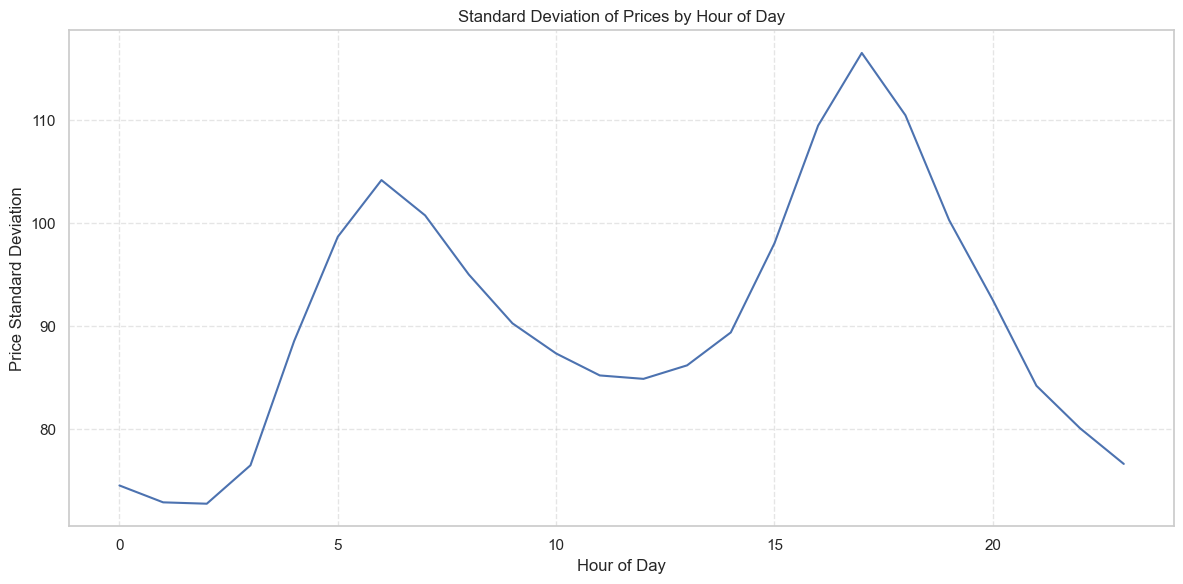

In [11]:
std_hourly = df_prices.groupby(df_prices.index.hour).std()
sns.set_theme(style="whitegrid")
plt.figure(figsize = (12,6))
plt.plot(std_hourly.index, std_hourly)
plt.xlabel("Hour of Day")
plt.ylabel("Price Standard Deviation")
plt.title("Standard Deviation of Prices by Hour of Day")
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
# plt.savefig("C:/Users/Startklar/Downloads/Price Std. Chart.png", dpi=300)
plt.show()

### Data Exploration

In [7]:
print(f"Earliest DateTime: {df_prices.index.min()}")
print(f"Latest DateTime: {df_prices.index.max()}")
# Check for missing values
print(df_prices.isnull().sum())

Earliest DateTime: 2018-09-30 22:00:00+00:00
Latest DateTime: 2025-11-16 23:00:00+00:00
Price    0
dtype: int64


# Import Weather Data
___
Using the historical weather API from open-meteo:
- https://open-meteo.com/en/docs/historical-weather-api
- Temperature is in Celsius
- Wind speed is in km/h
- Precipitation is in Millimeter


In [8]:
df_weather = pd.read_csv("../Data/Weather_hourly_final.csv")
df_weather["Timestamp"] = pd.to_datetime(df_weather["Timestamp"], utc=True)
df_weather = df_weather.set_index("Timestamp")
display(df_weather)

,Schleswig_Holstein_Temp,Schleswig_Holstein_Wind,Schleswig_Holstein_Cloud,Schleswig_Holstein_Precip,Niedersachsen_Temp,Niedersachsen_Wind,Niedersachsen_Cloud,Niedersachsen_Precip,Mecklenburg_Vorp_Temp,Mecklenburg_Vorp_Wind,...,Sachsen_Anhalt_Cloud,Sachsen_Anhalt_Precip,Thueringen_Temp,Thueringen_Wind,Thueringen_Cloud,Thueringen_Precip,Berlin_Temp,Berlin_Wind,Berlin_Cloud,Berlin_Precip
Timestamp,,,,,,,,,,,,,,,,,,,,,
2018-09-01 00:00:00+00:00,12.026,12.313894,24.0,0.0,11.108500,18.723461,52.0,0.0,12.739500,16.099690,...,16.0,0.0,11.063499,6.130579,16.0,0.0,12.4935,14.982228,6.0,0.0
2018-09-01 01:00:00+00:00,11.726,11.165805,35.0,0.0,10.108500,19.296135,7.0,0.0,12.239500,15.990646,...,28.0,0.0,10.013499,12.661564,20.0,0.0,11.0435,14.843180,60.0,0.0
2018-09-01 02:00:00+00:00,11.926,12.605142,36.0,0.0,9.808500,18.472595,22.0,0.0,12.189500,16.263872,...,32.0,0.0,8.963500,15.584300,31.0,0.0,10.9935,16.800856,25.0,0.0
2018-09-01 03:00:00+00:00,10.376,13.044723,100.0,0.0,9.658501,17.551615,32.0,0.0,12.189500,16.179985,...,30.0,0.0,10.063499,10.390226,99.0,0.0,10.2935,16.135872,41.0,0.0
2018-09-01 04:00:00+00:00,11.626,7.928177,100.0,0.0,9.908501,18.356470,30.0,0.0,12.339499,17.477621,...,35.0,0.0,8.263499,6.924738,99.0,0.0,9.9435,15.124284,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-23 19:00:00+00:00,0.926,42.744980,100.0,0.0,1.058500,32.800030,100.0,0.5,-2.460500,39.446290,...,100.0,0.0,-0.886500,32.460440,100.0,0.0,-3.1565,27.265692,30.0,0.0
2025-11-23 20:00:00+00:00,0.376,39.046310,100.0,0.4,0.308500,30.805777,100.0,0.7,-2.510500,38.156600,...,100.0,0.0,-0.586500,33.296104,100.0,0.1,-3.5065,27.309030,46.0,0.0
2025-11-23 21:00:00+00:00,-0.424,38.448017,100.0,0.6,0.208500,30.962095,100.0,0.5,-2.210500,37.799140,...,100.0,0.3,-0.136500,34.590454,100.0,0.0,-3.7565,28.113440,12.0,0.0


Perform a PCA on weather data
- https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html

In [9]:
df_weather_pca = df_weather.copy()
scaler_weather = StandardScaler()
df_weather_pca_scaled = scaler_weather.fit_transform(df_weather_pca)

pca = PCA(n_components=0.85)
df_ws_pca = pca.fit_transform(df_weather_pca_scaled)

pca_cols = []
for i in range(df_ws_pca.shape[1]):
    col_name = 'Weather_PCA' + str(i+1)
    pca_cols.append(col_name)

df_pca = pd.DataFrame(df_ws_pca, columns=pca_cols, index=df_weather.index)
df_pca

,Weather_PCA1,Weather_PCA2,Weather_PCA3,Weather_PCA4,Weather_PCA5,Weather_PCA6,Weather_PCA7,Weather_PCA8,Weather_PCA9,Weather_PCA10,...,Weather_PCA12,Weather_PCA13,Weather_PCA14,Weather_PCA15,Weather_PCA16,Weather_PCA17,Weather_PCA18,Weather_PCA19,Weather_PCA20,Weather_PCA21
Timestamp,,,,,,,,,,,,,,,,,,,,,
2018-09-01 00:00:00+00:00,2.309387,-2.365583,-1.444400,1.601173,0.979092,0.789897,0.379660,-1.154576,-0.550675,0.401346,...,-0.166397,-0.116153,-0.119055,0.174417,-0.552563,0.171418,-0.940571,-0.952897,0.417214,-0.325554
2018-09-01 01:00:00+00:00,1.893458,-2.516575,-1.723949,1.791532,0.815407,0.611419,0.597949,-1.238983,-0.390874,0.174570,...,-0.105093,-0.157847,-0.117688,0.105753,-0.286273,0.234712,-0.886291,-0.876633,0.222203,-0.055739
2018-09-01 02:00:00+00:00,1.552715,-2.263790,-1.465016,1.641908,0.830642,0.916706,0.712041,-1.346188,-0.618326,-0.053860,...,-0.233541,-0.058735,0.169356,-0.026935,-0.232577,0.518765,-0.964515,-1.079524,0.352057,-0.266451
2018-09-01 03:00:00+00:00,1.205682,-1.977679,-0.293207,1.176721,0.210974,0.924906,1.242067,-1.193391,-0.768217,0.089537,...,-0.160674,0.009117,0.171477,0.051418,-0.431122,0.728049,-1.346770,-1.333113,0.465589,-0.392531
2018-09-01 04:00:00+00:00,1.384896,-2.409510,-0.594990,1.509569,0.262057,0.192815,0.805313,-1.099555,-0.241580,0.811456,...,-0.154035,0.037615,0.452737,0.294234,-1.142789,0.754631,-1.399059,-1.699891,0.667016,-0.750896
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-23 19:00:00+00:00,-8.141424,1.603213,-0.682564,0.237094,1.304315,-2.500792,-0.599115,0.632934,0.100885,-0.362193,...,-0.229400,1.541684,-0.365483,-1.551073,-0.721407,-0.659396,-0.585881,-0.275309,1.967730,-0.965357
2025-11-23 20:00:00+00:00,-8.210965,1.953835,-0.162709,0.438191,0.252440,-2.368457,-0.758063,-0.075001,-0.471860,-0.272572,...,-0.308714,1.017588,-0.183870,-1.094850,-0.993438,0.164511,-0.657189,0.336723,0.904672,-0.524441
2025-11-23 21:00:00+00:00,-7.945264,1.680360,0.171266,0.564992,0.252397,-2.019482,-1.087895,0.101069,-0.560132,0.190819,...,0.496824,0.775830,0.019782,-0.623347,-0.680707,0.374111,0.005382,-0.383799,-0.282977,-1.117271


# Import of Commodity Prices
---
- All commodity prices were imported from Bloomberg (via Excel /BQL)
- The following tickers were used: NG1 Comdty, CO1 Comdty, and MO1 Comdty

### Natural Gas

In [10]:
natural_gas = pd.read_excel("../Data/NG1_COMB_Comdty_2010 to 2025.xlsx", header = None)

natural_gas.columns = ["DateTime", "Natural Gas Price"]
natural_gas["DateTime"] = pd.to_datetime(natural_gas["DateTime"], utc=True)
natural_gas = natural_gas.set_index("DateTime")

In [11]:
display(natural_gas.head())
print(f"Earliest DateTime: {natural_gas.index.min()}")
print(f"Latest DateTime: {natural_gas.index.max()}")
print(natural_gas.isnull().sum())

,Natural Gas Price
DateTime,
2010-01-04 00:00:00+00:00,5.884
2010-01-05 00:00:00+00:00,5.637
2010-01-06 00:00:00+00:00,6.009
2010-01-07 00:00:00+00:00,5.806
2010-01-08 00:00:00+00:00,5.749


Earliest DateTime: 2010-01-04 00:00:00+00:00
Latest DateTime: 2025-11-20 00:00:00+00:00
Natural Gas Price    0
dtype: int64


### Crude Oil (Brent)

In [12]:
crude_oil = pd.read_excel("../Data/CO1_Comdty_2010 to 2025.xlsx", header = None)
crude_oil.columns = ["DateTime", "Crude Oil Price"]
crude_oil["DateTime"] = pd.to_datetime(crude_oil["DateTime"], utc=True)
crude_oil = crude_oil.set_index("DateTime")
crude_oil

,Crude Oil Price
DateTime,
2010-01-04 00:00:00+00:00,80.12
2010-01-05 00:00:00+00:00,80.59
2010-01-06 00:00:00+00:00,81.89
2010-01-07 00:00:00+00:00,81.51
2010-01-08 00:00:00+00:00,81.37
...,...
2025-11-13 00:00:00+00:00,63.01
2025-11-14 00:00:00+00:00,64.39
2025-11-17 00:00:00+00:00,64.20


In [13]:
print(f"Earliest DateTime: {crude_oil.index.min()}")
print(f"Latest DateTime: {crude_oil.index.max()}")
print(crude_oil.isnull().sum())

Earliest DateTime: 2010-01-04 00:00:00+00:00
Latest DateTime: 2025-11-19 00:00:00+00:00
Crude Oil Price    0
dtype: int64


### EU Carbon Emissions

In [14]:
carbon_emissions = pd.read_excel("../Data/MO1_Comdty_2010 to 2025.xlsx", header = None)
carbon_emissions.columns = ["DateTime", "Carbon Emissions Price"]
carbon_emissions["DateTime"] = pd.to_datetime(carbon_emissions["DateTime"], utc=True)
carbon_emissions = carbon_emissions.set_index("DateTime")
carbon_emissions

,Carbon Emissions Price
DateTime,
2010-01-04 00:00:00+00:00,12.91
2010-01-05 00:00:00+00:00,12.52
2010-01-06 00:00:00+00:00,12.22
2010-01-07 00:00:00+00:00,12.57
2010-01-08 00:00:00+00:00,12.82
...,...
2025-11-13 00:00:00+00:00,81.34
2025-11-14 00:00:00+00:00,80.93
2025-11-17 00:00:00+00:00,79.92


In [15]:
print(f"Earliest DateTime: {carbon_emissions.index.min()}")
print(f"Latest DateTime: {carbon_emissions.index.max()}")
print(carbon_emissions.isnull().sum())

Earliest DateTime: 2010-01-04 00:00:00+00:00
Latest DateTime: 2025-11-19 00:00:00+00:00
Carbon Emissions Price    0
dtype: int64


# Import of Market Data
___
- Also all imported from Bloomberg via the Bloomberg Terminals at the University of St. Gallen
- THe tickers were GDBR2 Index, GDBR10 Index, and V1X Index

### Bond Yields

In [16]:
two_year = pd.read_excel("../Data/GDBR2 Index_2010 to 2025.xlsx", header = None)
two_year.columns = ["DateTime", "Yield"]
two_year["DateTime"] = pd.to_datetime(two_year["DateTime"], utc=True)
two_year = two_year.set_index("DateTime")
two_year

,Yield
DateTime,
2010-01-01 00:00:00+00:00,1.332
2010-01-04 00:00:00+00:00,1.347
2010-01-05 00:00:00+00:00,1.286
2010-01-06 00:00:00+00:00,1.294
2010-01-07 00:00:00+00:00,1.264
...,...
2025-11-13 00:00:00+00:00,2.028
2025-11-14 00:00:00+00:00,2.036
2025-11-17 00:00:00+00:00,2.042


In [17]:
print(f"Earliest DateTime: {two_year.index.min()}")
print(f"Latest DateTime: {two_year.index.max()}")
print(two_year.isnull().sum())

Earliest DateTime: 2010-01-01 00:00:00+00:00
Latest DateTime: 2025-11-19 00:00:00+00:00
Yield    0
dtype: int64


In [18]:
ten_year = pd.read_excel("../Data/GDBR10 Index_2010 to 2025.xlsx")
ten_year.columns = ["DateTime", "Yield"]
ten_year["DateTime"] = pd.to_datetime(ten_year["DateTime"], utc=True)
ten_year = ten_year.set_index("DateTime")
ten_year

,Yield
DateTime,
2010-01-04 00:00:00+00:00,3.391
2010-01-05 00:00:00+00:00,3.373
2010-01-06 00:00:00+00:00,3.381
2010-01-07 00:00:00+00:00,3.370
2010-01-08 00:00:00+00:00,3.385
...,...
2025-11-13 00:00:00+00:00,2.688
2025-11-14 00:00:00+00:00,2.720
2025-11-17 00:00:00+00:00,2.712


In [19]:
print(f"Earliest DateTime: {ten_year.index.min()}")
print(f"Latest DateTime: {ten_year.index.max()}")
print(ten_year.isnull().sum())

Earliest DateTime: 2010-01-04 00:00:00+00:00
Latest DateTime: 2025-11-19 00:00:00+00:00
Yield    0
dtype: int64


In [20]:
bond_yield_difference = ten_year.copy()
bond_yield_difference["Difference"] = bond_yield_difference["Yield"] - two_year["Yield"]
bond_yield_difference.drop(columns=["Yield"], inplace=True)
bond_yield_difference

,Difference
DateTime,
2010-01-04 00:00:00+00:00,2.044
2010-01-05 00:00:00+00:00,2.087
2010-01-06 00:00:00+00:00,2.087
2010-01-07 00:00:00+00:00,2.106
2010-01-08 00:00:00+00:00,2.141
...,...
2025-11-13 00:00:00+00:00,0.660
2025-11-14 00:00:00+00:00,0.684
2025-11-17 00:00:00+00:00,0.670


### VDAX

In [21]:
vdax = pd.read_excel("../Data/V1X Index_2010 to 2025.xlsx")
vdax.columns = ["DateTime", "VDax"]
vdax['DateTime'] = pd.to_datetime(vdax['DateTime'], utc=True)
vdax = vdax.set_index("DateTime")
vdax

,VDax
DateTime,
2010-01-05 00:00:00+00:00,21.96
2010-01-06 00:00:00+00:00,21.63
2010-01-07 00:00:00+00:00,21.72
2010-01-08 00:00:00+00:00,20.87
2010-01-11 00:00:00+00:00,21.56
...,...
2025-11-13 00:00:00+00:00,18.48
2025-11-14 00:00:00+00:00,19.15
2025-11-17 00:00:00+00:00,20.50


In [22]:
print(f"Earliest DateTime: {vdax.index.min()}")
print(f"Latest DateTime: {vdax.index.max()}")
print(vdax.isnull().sum())

Earliest DateTime: 2010-01-05 00:00:00+00:00
Latest DateTime: 2025-11-19 00:00:00+00:00
VDax    0
dtype: int64


# Generation Activity
---
- Imported from ENTSO-E through the API

In [23]:
generation = pd.read_csv("../Data/Generation_hourly.csv", low_memory = False)
generation.rename(columns={"DateDate":"DateTime"}, inplace=True)
generation["DateTime"] = pd.to_datetime(generation["DateTime"])
generation.set_index("DateTime")
print(generation.head(0))

Empty DataFrame
Columns: [DateTime, BiomassActual Aggregated, Fossil Brown coal/LigniteActual Aggregated, Fossil Coal-derived gasActual Aggregated, Fossil GasActual Aggregated, Fossil GasActual Consumption, Fossil Hard coalActual Aggregated, Fossil OilActual Aggregated, Fossil OilActual Consumption, GeothermalActual Aggregated, Hydro Pumped StorageActual Aggregated, Hydro Pumped StorageActual Consumption, Hydro Run-of-river and poundageActual Aggregated, Hydro Water ReservoirActual Aggregated, Hydro Water ReservoirActual Consumption, NuclearActual Aggregated, NuclearActual Consumption, OtherActual Aggregated, Other renewableActual Aggregated, Other renewableActual Consumption, SolarActual Aggregated, SolarActual Consumption, WasteActual Aggregated, Wind OffshoreActual Aggregated, Wind OnshoreActual Aggregated, Wind OnshoreActual Consumption]
Index: []

[0 rows x 26 columns]


In [24]:
print(generation.isna().sum())
generation['Hydro Pumped Storage Net'] = generation['Hydro Pumped StorageActual Aggregated'] - generation['Hydro Pumped StorageActual Consumption']
# this step is needed to find the actual contribution of hydro energy to the grid


generation_short = generation.drop(columns=["Fossil Coal-derived gasActual Aggregated", "Fossil GasActual Consumption", "Fossil OilActual Consumption", "Hydro Water ReservoirActual Consumption", "NuclearActual Aggregated", "NuclearActual Consumption", "Other renewableActual Consumption", "SolarActual Consumption", "Wind OnshoreActual Consumption", "Hydro Pumped StorageActual Consumption", "Hydro Pumped StorageActual Aggregated"])
generation_short.set_index("DateTime", inplace=True)
print("\n",generation_short.isna().sum())

print(generation_short.tail())
generation_short

DateTime                                                0
BiomassActual Aggregated                                0
Fossil Brown coal/LigniteActual Aggregated              0
Fossil Coal-derived gasActual Aggregated            29833
Fossil GasActual Aggregated                             0
Fossil GasActual Consumption                        44074
Fossil Hard coalActual Aggregated                       0
Fossil OilActual Aggregated                             0
Fossil OilActual Consumption                        35233
GeothermalActual Aggregated                             0
Hydro Pumped StorageActual Aggregated                   0
Hydro Pumped StorageActual Consumption                  0
Hydro Run-of-river and poundageActual Aggregated        0
Hydro Water ReservoirActual Aggregated                  5
Hydro Water ReservoirActual Consumption             37355
NuclearActual Aggregated                            22705
NuclearActual Consumption                           56495
OtherActual Ag

,BiomassActual Aggregated,Fossil Brown coal/LigniteActual Aggregated,Fossil GasActual Aggregated,Fossil Hard coalActual Aggregated,Fossil OilActual Aggregated,GeothermalActual Aggregated,Hydro Run-of-river and poundageActual Aggregated,Hydro Water ReservoirActual Aggregated,OtherActual Aggregated,Other renewableActual Aggregated,SolarActual Aggregated,WasteActual Aggregated,Wind OffshoreActual Aggregated,Wind OnshoreActual Aggregated,Hydro Pumped Storage Net
DateTime,,,,,,,,,,,,,,,
2018-09-30 22:00:00+00:00,4416.220000,15545.335000,3391.750000,7945.967500,543.150000,22.18000,1167.535000,174.005000,322.85250,132.6575,0.85250,926.93750,1632.37250,4223.480000,-3441.495000
2018-09-30 23:00:00+00:00,4388.802500,15605.847500,3257.537500,7761.457500,528.730000,22.23250,1174.042500,72.627500,322.90500,131.6075,0.85000,926.26250,2078.02750,3948.330000,-3945.015000
2018-10-01 00:00:00+00:00,4390.942500,15685.622500,3336.512500,7556.695000,528.105000,21.98500,1187.150000,90.235000,322.81250,131.5150,0.55750,937.38750,2141.55000,3918.442500,-3868.640000
2018-10-01 01:00:00+00:00,4374.492500,15753.332500,3179.512500,7924.147500,529.777500,21.72750,1191.235000,45.250000,322.90000,130.9400,0.56250,939.36000,2198.15000,4096.237500,-4895.840000
2018-10-01 02:00:00+00:00,4382.490000,15814.230000,3370.735000,8221.690000,528.355000,21.98000,1192.205000,42.722500,322.73500,130.5525,0.58750,944.44000,2556.36250,4561.685000,-5387.857500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-16 18:00:00+00:00,4778.273935,9930.108660,10937.191732,3943.455495,351.475000,22.60905,1036.889688,80.246125,314.02517,72.4510,0.04300,843.19675,4000.32200,7008.568760,2322.168675
2025-11-16 19:00:00+00:00,4658.867435,9858.382308,11003.383347,3810.859267,351.755832,22.60905,1030.230690,112.804425,314.25067,72.4510,0.04475,828.75350,4790.50825,8131.155517,366.218425
2025-11-16 20:00:00+00:00,4537.330510,9694.949955,10398.292135,3617.695390,351.740833,22.60905,1020.718855,75.791975,303.32642,72.4510,0.04375,837.56125,5463.96400,8972.253205,-25.722000


# Load Data (ENTSO-E)
---
- From SMARD, had to be downloaded in four parts since only two years could be downloaded at a time

In [25]:
load_1= pd.read_csv("../Data/Actual_consumption_202311280000_202511290000_Hour.csv", sep = ";", parse_dates =["End date"], na_values = "-", thousands = ",", decimal = ".")
df_load_1 = load_1[["End date", "grid load [MWh] Calculated resolutions"]]
df_load_1 = df_load_1.rename(columns={"End date":"DateTime", "grid load [MWh] Calculated resolutions":"Load"})
df_load_1.set_index("DateTime", inplace=True)
df_load_1["Load"] = df_load_1["Load"].astype(float)

print(df_load_1.head())
print(df_load_1.tail(48))
print(df_load_1.isna().sum())
print(df_load_1.isnull().sum())
print(df_load_1)

load_2 = pd.read_csv("../Data/Actual_consumption_202111280000_202311280000_Hour.csv", sep=";", parse_dates =["End date"], na_values = "-", thousands = ",", decimal = ".")
df_load_2 = load_2[["End date", "grid load [MWh] Calculated resolutions"]]
df_load_2 = df_load_2.rename(columns={"End date":"DateTime", "grid load [MWh] Calculated resolutions":"Load"})
df_load_2.set_index("DateTime", inplace=True)
df_load_2["Load"] = df_load_2["Load"].astype(float)
print(df_load_2)

load_3 = pd.read_csv("../Data/Actual_consumption_201911280000_202111280000_Hour.csv", sep=";", parse_dates =["End date"], na_values = "-", thousands = ",", decimal = ".")
df_load_3 = load_3[["End date", "grid load [MWh] Calculated resolutions"]]
df_load_3 = df_load_3.rename(columns={"End date":"DateTime", "grid load [MWh] Calculated resolutions":"Load"})
df_load_3.set_index("DateTime", inplace=True)
df_load_3["Load"] = df_load_3["Load"].astype(float)
print(df_load_3)

load_4 = pd.read_csv("../Data/Actual_consumption_201810010000_201911280000_Hour.csv", sep=";", parse_dates =["End date"], na_values = "-", thousands = ",", decimal = ".")
df_load_4 = load_4[["End date", "grid load [MWh] Calculated resolutions"]]
df_load_4 = df_load_4.rename(columns={"End date":"DateTime", "grid load [MWh] Calculated resolutions":"Load"})
df_load_4.set_index("DateTime", inplace=True)
df_load_4["Load"] = df_load_4["Load"].astype(float)
print(df_load_4)

df_load = pd.concat([df_load_4, df_load_3, df_load_2, df_load_1])
df_load.dropna(inplace=True)
df_load.index = pd.to_datetime(df_load.index, errors="coerce")

                        Load
DateTime                    
2023-11-28 01:00:00  53315.0
2023-11-28 02:00:00  51429.5
2023-11-28 03:00:00  50408.0
2023-11-28 04:00:00  50633.5
2023-11-28 05:00:00  51811.0
                     Load
DateTime                 
2025-11-27 01:00:00   NaN
2025-11-27 02:00:00   NaN
2025-11-27 03:00:00   NaN
2025-11-27 04:00:00   NaN
2025-11-27 05:00:00   NaN
2025-11-27 06:00:00   NaN
2025-11-27 07:00:00   NaN
2025-11-27 08:00:00   NaN
2025-11-27 09:00:00   NaN
2025-11-27 10:00:00   NaN
2025-11-27 11:00:00   NaN
2025-11-27 12:00:00   NaN
2025-11-27 13:00:00   NaN
2025-11-27 14:00:00   NaN
2025-11-27 15:00:00   NaN
2025-11-27 16:00:00   NaN
2025-11-27 17:00:00   NaN
2025-11-27 18:00:00   NaN
2025-11-27 19:00:00   NaN
2025-11-27 20:00:00   NaN
2025-11-27 21:00:00   NaN
2025-11-27 22:00:00   NaN
2025-11-27 23:00:00   NaN
2025-11-28 00:00:00   NaN
2025-11-28 01:00:00   NaN
2025-11-28 02:00:00   NaN
2025-11-28 03:00:00   NaN
2025-11-28 04:00:00   NaN
2025-11-28 05:00:

In [26]:
df = df_load.copy()

df.index = pd.to_datetime(df.index, errors="coerce") # had quite some trouble with the datetime index for this dataset, here making sure its correctly parsed as datetime
df = df[~df.index.isna()] # if for some reason it failed to parse, those rows are dropped

df = df.sort_index() # just in case, but should already be in chronological order

df = df[~df.index.duplicated(keep="first")] # gets rid of any duplicate time stamps and only keeps the first one

ber = pytz.timezone("Europe/Berlin") # prepare a Berlin timezone object

def localize_ts(ts): # we made a function that localizes a naive timezone to Europe / Berlin and therefore handles any DST anomalies
    dt = ts.to_pydatetime()
    try:
        return ber.localize(dt, is_dst=None) # first simply try normal localization
    except pytz.AmbiguousTimeError:
        return ber.localize(dt, is_dst=True) # for fall DST (duplicate hour)
    except pytz.NonExistentTimeError:
        return ber.localize(dt + pd.Timedelta(hours=1), is_dst=False) # for spring DST (missing hour): this shifts it forward to the first valid time

localized = [localize_ts(ts) for ts in df.index] #then simply apply it to each timestamp

# Then convert to UTC
df.index = pd.DatetimeIndex(localized).tz_convert("UTC")

df_load = df
df_load

,Load
2018-10-01 00:00:00+00:00,42064.50
2018-10-01 01:00:00+00:00,41274.50
2018-10-01 02:00:00+00:00,42095.50
2018-10-01 03:00:00+00:00,43659.00
2018-10-01 04:00:00+00:00,48028.75
...,...
2025-11-26 19:00:00+00:00,71330.93
2025-11-26 20:00:00+00:00,67391.95
2025-11-26 21:00:00+00:00,64016.57
2025-11-26 22:00:00+00:00,60909.17


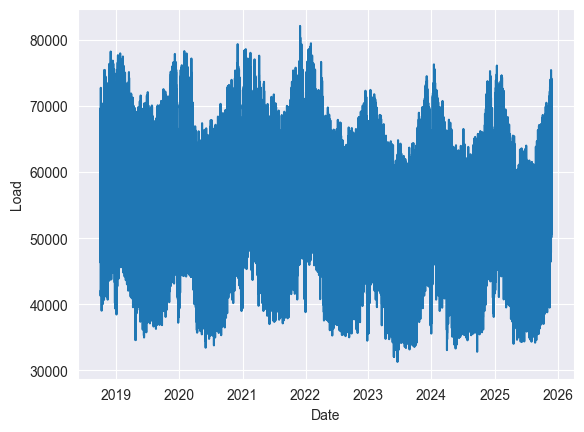

In [27]:
plt.plot(df_load)
plt.xlabel("Date")
plt.ylabel("Load")
plt.show()

### Combined feature dataframe


In [28]:
daily_data_market = pd.concat([natural_gas, crude_oil, carbon_emissions, bond_yield_difference, vdax], axis=1, join='outer')

df_hourly_data_market = daily_data_market.resample('h').ffill() #just uses the price of a day and fills it for every hour, as only daily data was available. downside is that this makes it look less volatile than it is
df_hourly_data_market

,Natural Gas Price,Crude Oil Price,Carbon Emissions Price,Difference,VDax
DateTime,,,,,
2010-01-04 00:00:00+00:00,5.884,80.12,12.91,2.044,NaN
2010-01-04 01:00:00+00:00,5.884,80.12,12.91,2.044,NaN
2010-01-04 02:00:00+00:00,5.884,80.12,12.91,2.044,NaN
2010-01-04 03:00:00+00:00,5.884,80.12,12.91,2.044,NaN
2010-01-04 04:00:00+00:00,5.884,80.12,12.91,2.044,NaN
...,...,...,...,...,...
2025-11-19 20:00:00+00:00,4.550,63.51,80.66,0.693,22.96
2025-11-19 21:00:00+00:00,4.550,63.51,80.66,0.693,22.96
2025-11-19 22:00:00+00:00,4.550,63.51,80.66,0.693,22.96


In [29]:
df_data_hourly_without_weather = generation_short.join(df_hourly_data_market, how='left')
df_data_hourly_without_weather

,BiomassActual Aggregated,Fossil Brown coal/LigniteActual Aggregated,Fossil GasActual Aggregated,Fossil Hard coalActual Aggregated,Fossil OilActual Aggregated,GeothermalActual Aggregated,Hydro Run-of-river and poundageActual Aggregated,Hydro Water ReservoirActual Aggregated,OtherActual Aggregated,Other renewableActual Aggregated,SolarActual Aggregated,WasteActual Aggregated,Wind OffshoreActual Aggregated,Wind OnshoreActual Aggregated,Hydro Pumped Storage Net,Natural Gas Price,Crude Oil Price,Carbon Emissions Price,Difference,VDax
DateTime,,,,,,,,,,,,,,,,,,,,
2018-09-30 22:00:00+00:00,4416.220000,15545.335000,3391.750000,7945.967500,543.150000,22.18000,1167.535000,174.005000,322.85250,132.6575,0.85250,926.93750,1632.37250,4223.480000,-3441.495000,3.008,82.72,21.21,0.993,15.18
2018-09-30 23:00:00+00:00,4388.802500,15605.847500,3257.537500,7761.457500,528.730000,22.23250,1174.042500,72.627500,322.90500,131.6075,0.85000,926.26250,2078.02750,3948.330000,-3945.015000,3.008,82.72,21.21,0.993,15.18
2018-10-01 00:00:00+00:00,4390.942500,15685.622500,3336.512500,7556.695000,528.105000,21.98500,1187.150000,90.235000,322.81250,131.5150,0.55750,937.38750,2141.55000,3918.442500,-3868.640000,3.094,84.98,21.37,1.012,14.65
2018-10-01 01:00:00+00:00,4374.492500,15753.332500,3179.512500,7924.147500,529.777500,21.72750,1191.235000,45.250000,322.90000,130.9400,0.56250,939.36000,2198.15000,4096.237500,-4895.840000,3.094,84.98,21.37,1.012,14.65
2018-10-01 02:00:00+00:00,4382.490000,15814.230000,3370.735000,8221.690000,528.355000,21.98000,1192.205000,42.722500,322.73500,130.5525,0.58750,944.44000,2556.36250,4561.685000,-5387.857500,3.094,84.98,21.37,1.012,14.65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-16 18:00:00+00:00,4778.273935,9930.108660,10937.191732,3943.455495,351.475000,22.60905,1036.889688,80.246125,314.02517,72.4510,0.04300,843.19675,4000.32200,7008.568760,2322.168675,4.566,64.39,80.93,0.684,19.15
2025-11-16 19:00:00+00:00,4658.867435,9858.382308,11003.383347,3810.859267,351.755832,22.60905,1030.230690,112.804425,314.25067,72.4510,0.04475,828.75350,4790.50825,8131.155517,366.218425,4.566,64.39,80.93,0.684,19.15
2025-11-16 20:00:00+00:00,4537.330510,9694.949955,10398.292135,3617.695390,351.740833,22.60905,1020.718855,75.791975,303.32642,72.4510,0.04375,837.56125,5463.96400,8972.253205,-25.722000,4.566,64.39,80.93,0.684,19.15


In [30]:
df_data_hourly_noload = df_data_hourly_without_weather.join(df_pca, how='left')
df_data_hourly = df_data_hourly_noload.join(df_load, how='left')
df_data_hourly

,BiomassActual Aggregated,Fossil Brown coal/LigniteActual Aggregated,Fossil GasActual Aggregated,Fossil Hard coalActual Aggregated,Fossil OilActual Aggregated,GeothermalActual Aggregated,Hydro Run-of-river and poundageActual Aggregated,Hydro Water ReservoirActual Aggregated,OtherActual Aggregated,Other renewableActual Aggregated,...,Weather_PCA13,Weather_PCA14,Weather_PCA15,Weather_PCA16,Weather_PCA17,Weather_PCA18,Weather_PCA19,Weather_PCA20,Weather_PCA21,Load
DateTime,,,,,,,,,,,,,,,,,,,,,
2018-09-30 22:00:00+00:00,4416.220000,15545.335000,3391.750000,7945.967500,543.150000,22.18000,1167.535000,174.005000,322.85250,132.6575,...,0.337753,0.040668,0.452048,-0.127025,0.356252,-0.446410,-0.544138,0.207679,-0.375253,NaN
2018-09-30 23:00:00+00:00,4388.802500,15605.847500,3257.537500,7761.457500,528.730000,22.23250,1174.042500,72.627500,322.90500,131.6075,...,0.348088,0.023518,0.017366,-0.056672,0.059828,-0.703888,-0.237819,0.064114,0.031616,NaN
2018-10-01 00:00:00+00:00,4390.942500,15685.622500,3336.512500,7556.695000,528.105000,21.98500,1187.150000,90.235000,322.81250,131.5150,...,0.359510,-0.190257,-0.155739,0.787589,0.145932,-0.906755,-0.126726,-0.192568,0.290348,42064.50
2018-10-01 01:00:00+00:00,4374.492500,15753.332500,3179.512500,7924.147500,529.777500,21.72750,1191.235000,45.250000,322.90000,130.9400,...,0.360313,-0.086312,0.214732,0.348146,0.194680,-0.796612,-0.488341,0.188421,-0.004564,41274.50
2018-10-01 02:00:00+00:00,4382.490000,15814.230000,3370.735000,8221.690000,528.355000,21.98000,1192.205000,42.722500,322.73500,130.5525,...,0.233432,0.208331,0.278013,-0.206237,0.143102,-0.726320,-0.523832,0.123280,-0.003052,42095.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-16 18:00:00+00:00,4778.273935,9930.108660,10937.191732,3943.455495,351.475000,22.60905,1036.889688,80.246125,314.02517,72.4510,...,-0.378477,-0.604784,-0.302593,-0.418019,0.418821,-0.184771,-0.773112,0.012618,-0.508731,56625.86
2025-11-16 19:00:00+00:00,4658.867435,9858.382308,11003.383347,3810.859267,351.755832,22.60905,1030.230690,112.804425,314.25067,72.4510,...,-0.279584,-0.583593,-0.340275,0.215861,0.196803,-0.488126,-0.214482,-0.506907,-0.062238,54731.60
2025-11-16 20:00:00+00:00,4537.330510,9694.949955,10398.292135,3617.695390,351.740833,22.60905,1020.718855,75.791975,303.32642,72.4510,...,-0.769863,-0.585700,-0.721259,0.110143,0.074717,-0.110753,-0.687521,-1.177536,-0.679346,53188.14


The df_data_hourly is all our features in one df.
Now we also want to have a df with features and our price – thus creating another df with the price

In [31]:
df_data_final = df_prices.join(df_data_hourly,  how='left')
df_data_final.rename(columns={"Difference":"Bond Yield Difference"}, inplace=True)
df_data_final = df_data_final.iloc[:-1] # drop last row that is full of NaNs
df_data_final = df_data_final.fillna(method='ffill')
df_data_final = df_data_final.fillna(method='bfill')
df_data_final

/var/folders/hr/rcbnj_fs4pd2b0zkz9ccr89m0000gn/T/ipykernel_1193/2822251555.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_data_final = df_data_final.fillna(method='ffill')
/var/folders/hr/rcbnj_fs4pd2b0zkz9ccr89m0000gn/T/ipykernel_1193/2822251555.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_data_final = df_data_final.fillna(method='bfill')


,Price,BiomassActual Aggregated,Fossil Brown coal/LigniteActual Aggregated,Fossil GasActual Aggregated,Fossil Hard coalActual Aggregated,Fossil OilActual Aggregated,GeothermalActual Aggregated,Hydro Run-of-river and poundageActual Aggregated,Hydro Water ReservoirActual Aggregated,OtherActual Aggregated,...,Weather_PCA13,Weather_PCA14,Weather_PCA15,Weather_PCA16,Weather_PCA17,Weather_PCA18,Weather_PCA19,Weather_PCA20,Weather_PCA21,Load
DateTime,,,,,,,,,,,,,,,,,,,,,
2018-09-30 22:00:00+00:00,59.5300,4416.220000,15545.335000,3391.750000,7945.967500,543.150000,22.18000,1167.535000,174.005000,322.85250,...,0.337753,0.040668,0.452048,-0.127025,0.356252,-0.446410,-0.544138,0.207679,-0.375253,42064.50
2018-09-30 23:00:00+00:00,56.1000,4388.802500,15605.847500,3257.537500,7761.457500,528.730000,22.23250,1174.042500,72.627500,322.90500,...,0.348088,0.023518,0.017366,-0.056672,0.059828,-0.703888,-0.237819,0.064114,0.031616,42064.50
2018-10-01 00:00:00+00:00,51.4100,4390.942500,15685.622500,3336.512500,7556.695000,528.105000,21.98500,1187.150000,90.235000,322.81250,...,0.359510,-0.190257,-0.155739,0.787589,0.145932,-0.906755,-0.126726,-0.192568,0.290348,42064.50
2018-10-01 01:00:00+00:00,47.3800,4374.492500,15753.332500,3179.512500,7924.147500,529.777500,21.72750,1191.235000,45.250000,322.90000,...,0.360313,-0.086312,0.214732,0.348146,0.194680,-0.796612,-0.488341,0.188421,-0.004564,41274.50
2018-10-01 02:00:00+00:00,47.5900,4382.490000,15814.230000,3370.735000,8221.690000,528.355000,21.98000,1192.205000,42.722500,322.73500,...,0.233432,0.208331,0.278013,-0.206237,0.143102,-0.726320,-0.523832,0.123280,-0.003052,42095.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-16 18:00:00+00:00,115.3300,4778.273935,9930.108660,10937.191732,3943.455495,351.475000,22.60905,1036.889688,80.246125,314.02517,...,-0.378477,-0.604784,-0.302593,-0.418019,0.418821,-0.184771,-0.773112,0.012618,-0.508731,56625.86
2025-11-16 19:00:00+00:00,102.7175,4658.867435,9858.382308,11003.383347,3810.859267,351.755832,22.60905,1030.230690,112.804425,314.25067,...,-0.279584,-0.583593,-0.340275,0.215861,0.196803,-0.488126,-0.214482,-0.506907,-0.062238,54731.60
2025-11-16 20:00:00+00:00,91.4100,4537.330510,9694.949955,10398.292135,3617.695390,351.740833,22.60905,1020.718855,75.791975,303.32642,...,-0.769863,-0.585700,-0.721259,0.110143,0.074717,-0.110753,-0.687521,-1.177536,-0.679346,53188.14


### Calendar features + lagged features

In [32]:
# Shift all predictors by 24 hours so they're available at the time of prediction
predictor_cols = df_data_final.drop(columns="Price").columns

df_data_final[predictor_cols] = df_data_final[predictor_cols].shift(24)

# Drop rows with NaNs caused by the shift
df_data_final = df_data_final.dropna()
df_data_final

,Price,BiomassActual Aggregated,Fossil Brown coal/LigniteActual Aggregated,Fossil GasActual Aggregated,Fossil Hard coalActual Aggregated,Fossil OilActual Aggregated,GeothermalActual Aggregated,Hydro Run-of-river and poundageActual Aggregated,Hydro Water ReservoirActual Aggregated,OtherActual Aggregated,...,Weather_PCA13,Weather_PCA14,Weather_PCA15,Weather_PCA16,Weather_PCA17,Weather_PCA18,Weather_PCA19,Weather_PCA20,Weather_PCA21,Load
DateTime,,,,,,,,,,,,,,,,,,,,,
2018-10-01 22:00:00+00:00,45.1000,4416.220000,15545.335000,3391.750000,7945.967500,543.150000,22.18000,1167.535000,174.005000,322.85250,...,0.337753,0.040668,0.452048,-0.127025,0.356252,-0.446410,-0.544138,0.207679,-0.375253,42064.50
2018-10-01 23:00:00+00:00,44.1000,4388.802500,15605.847500,3257.537500,7761.457500,528.730000,22.23250,1174.042500,72.627500,322.90500,...,0.348088,0.023518,0.017366,-0.056672,0.059828,-0.703888,-0.237819,0.064114,0.031616,42064.50
2018-10-02 00:00:00+00:00,44.0600,4390.942500,15685.622500,3336.512500,7556.695000,528.105000,21.98500,1187.150000,90.235000,322.81250,...,0.359510,-0.190257,-0.155739,0.787589,0.145932,-0.906755,-0.126726,-0.192568,0.290348,42064.50
2018-10-02 01:00:00+00:00,43.7700,4374.492500,15753.332500,3179.512500,7924.147500,529.777500,21.72750,1191.235000,45.250000,322.90000,...,0.360313,-0.086312,0.214732,0.348146,0.194680,-0.796612,-0.488341,0.188421,-0.004564,41274.50
2018-10-02 02:00:00+00:00,44.2900,4382.490000,15814.230000,3370.735000,8221.690000,528.355000,21.98000,1192.205000,42.722500,322.73500,...,0.233432,0.208331,0.278013,-0.206237,0.143102,-0.726320,-0.523832,0.123280,-0.003052,42095.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-16 18:00:00+00:00,115.3300,4769.734185,8185.276598,10761.162360,3273.594927,353.016000,22.60905,1108.430582,78.625350,314.33742,...,0.961238,-0.170099,0.924773,0.082435,-0.270592,-0.162538,0.115864,0.671916,-0.026183,57957.47
2025-11-16 19:00:00+00:00,102.7175,4628.288510,7957.060780,10058.746128,2823.872720,353.082668,22.60905,1107.514950,56.044100,304.62092,...,0.005843,-0.044899,0.217718,-0.262313,0.043270,-0.528971,-0.257639,0.495282,-0.093508,55547.17
2025-11-16 20:00:00+00:00,91.4100,4487.375260,7862.903975,9066.489525,2894.926815,353.117668,22.60905,1102.033235,77.328925,303.99717,...,-1.538178,1.535022,-0.120800,1.151733,-0.386156,-0.670711,1.275218,1.380062,-0.522988,53094.38


In [33]:
# Only adding calendar and lagged features after the 24h shift so that those are not also shifted
df_data_final["hour"] = df_data_final.index.hour
df_data_final["dayofweek"] = df_data_final.index.dayofweek
df_data_final["day_of_year"] = df_data_final.index.dayofyear

df_data_final["Lag24"] = df_data_final["Price"].shift(24)
df_data_final["Lag48"] = df_data_final["Price"].shift(48)
df_data_final["Lag168"] = df_data_final["Price"].shift(168)
df_data_final = df_data_final.dropna() # drop first couple missing rows

df_data_final_lstm = df_data_final.copy()
df_data_final

/var/folders/hr/rcbnj_fs4pd2b0zkz9ccr89m0000gn/T/ipykernel_1193/564702987.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_data_final["hour"] = df_data_final.index.hour
/var/folders/hr/rcbnj_fs4pd2b0zkz9ccr89m0000gn/T/ipykernel_1193/564702987.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_data_final["dayofweek"] = df_data_final.index.dayofweek
/var/folders/hr/rcbnj_fs4pd2b0zkz9ccr89m0000gn/T/ipykernel_1193/564702987.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slic

,Price,BiomassActual Aggregated,Fossil Brown coal/LigniteActual Aggregated,Fossil GasActual Aggregated,Fossil Hard coalActual Aggregated,Fossil OilActual Aggregated,GeothermalActual Aggregated,Hydro Run-of-river and poundageActual Aggregated,Hydro Water ReservoirActual Aggregated,OtherActual Aggregated,...,Weather_PCA19,Weather_PCA20,Weather_PCA21,Load,hour,dayofweek,day_of_year,Lag24,Lag48,Lag168
DateTime,,,,,,,,,,,,,,,,,,,,,
2018-10-08 22:00:00+00:00,56.7700,4101.282500,12994.872500,3595.555000,11322.127500,501.617500,20.55500,1181.337500,66.262500,376.21250,...,-0.681964,0.222181,-0.175893,45565.50,22,0,281,55.5900,50.4900,45.1000
2018-10-08 23:00:00+00:00,57.4300,4108.977500,13202.392500,3616.215000,10698.460000,507.005000,20.74500,1189.952500,111.690000,377.09000,...,-0.382329,0.178475,-0.087217,43839.25,23,0,281,50.3000,47.1100,44.1000
2018-10-09 00:00:00+00:00,55.1100,4090.887500,13401.335000,3477.035000,10598.420000,508.592500,20.93000,1186.742500,101.367500,378.22000,...,0.129495,0.236008,-0.400032,42569.00,0,1,282,50.1600,45.7500,44.0600
2018-10-09 01:00:00+00:00,52.3500,4100.332500,13460.020000,3637.202500,10634.180000,508.212500,20.77000,1178.390000,79.342500,383.94000,...,0.189345,-0.134113,0.252045,42263.00,1,1,282,47.3200,43.0200,43.7700
2018-10-09 02:00:00+00:00,54.8600,4100.817500,13520.675000,3768.297500,10946.525000,509.552500,20.65000,1180.245000,98.657500,377.94000,...,0.107388,-0.174516,0.345401,42749.50,2,1,282,47.9400,42.5000,44.2900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-16 18:00:00+00:00,115.3300,4769.734185,8185.276598,10761.162360,3273.594927,353.016000,22.60905,1108.430582,78.625350,314.33742,...,0.115864,0.671916,-0.026183,57957.47,18,6,320,114.0650,106.4900,117.9550
2025-11-16 19:00:00+00:00,102.7175,4628.288510,7957.060780,10058.746128,2823.872720,353.082668,22.60905,1107.514950,56.044100,304.62092,...,-0.257639,0.495282,-0.093508,55547.17,19,6,320,109.1250,98.9150,106.0000
2025-11-16 20:00:00+00:00,91.4100,4487.375260,7862.903975,9066.489525,2894.926815,353.117668,22.60905,1102.033235,77.328925,303.99717,...,1.275218,1.380062,-0.522988,53094.38,20,6,320,102.8850,93.1625,93.5375


# Data Inspection and Visualization
___

### Day-ahead prices

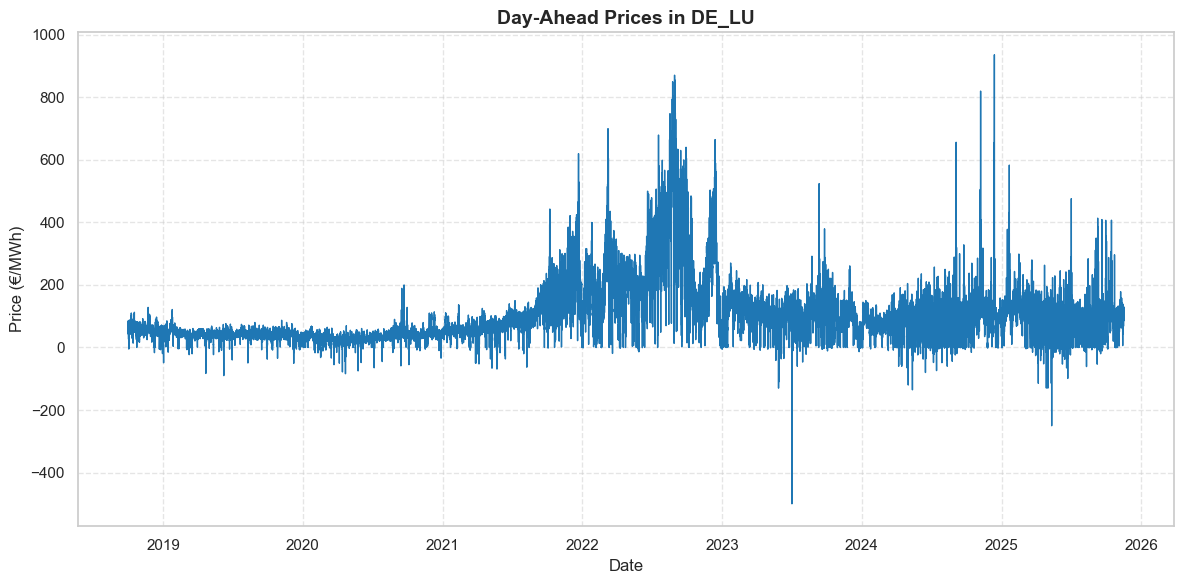

In [34]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12, 6))
plt.plot(df_prices, linewidth=1, color="#1f77b4")  # slightly thicker and nicer color
plt.xlabel("Date", fontsize=12)
plt.ylabel("Price (€/MWh)", fontsize=12)
plt.title("Day-Ahead Prices in DE_LU", fontsize=14, weight='bold')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

# plt.savefig("C:/Users/Startklar/Downloads/Day Ahead Price Chart.png", dpi=300)
plt.show()

In [35]:
print(f"Lowest Price:{df_prices.min()}")
print(f"Highest Price:{df_prices.max()}")
print(f"Negative Value Count: {df_prices["Price"].lt(0).sum()}")

Lowest Price:Price   -500.0
dtype: float64
Highest Price:Price    936.28
dtype: float64
Negative Value Count: 2077


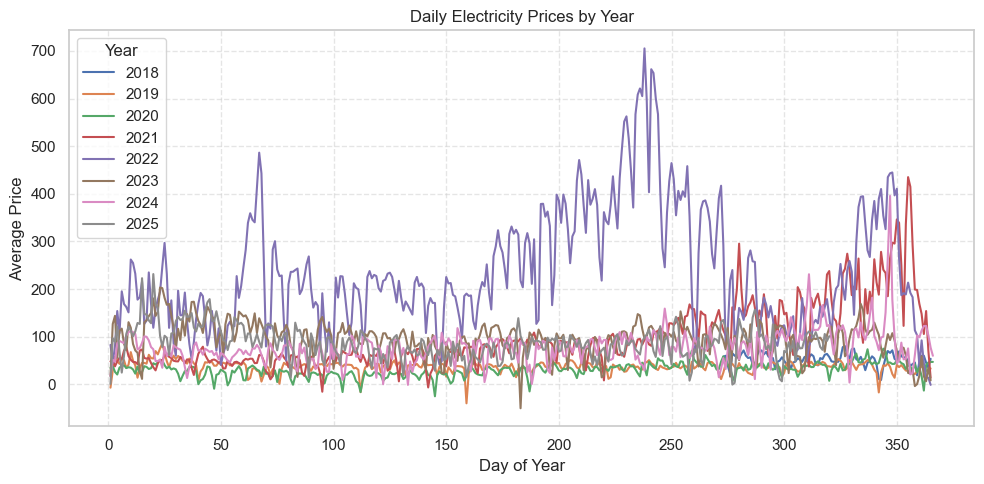

In [36]:
# Annual Seasonality
prices_yearly = df_prices.copy()
prices_yearly["year"] = prices_yearly.index.year
prices_yearly["day"] = prices_yearly.index.dayofyear

daily_avg = prices_yearly.groupby(["year", "day"])["Price"].mean().reset_index()
daily_pivot = daily_avg.pivot(index="day", columns="year", values="Price")

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10,5))
for year in daily_pivot.columns:
    plt.plot(daily_pivot.index, daily_pivot[year], label=str(year))
plt.xlabel('Day of Year')
plt.ylabel('Average Price')
plt.title('Daily Electricity Prices by Year')
plt.legend(title='Year')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
#plt.savefig("C:/Users/Startklar/Downloads/Day Ahead Prices By Year.png", dpi=300)
plt.show()

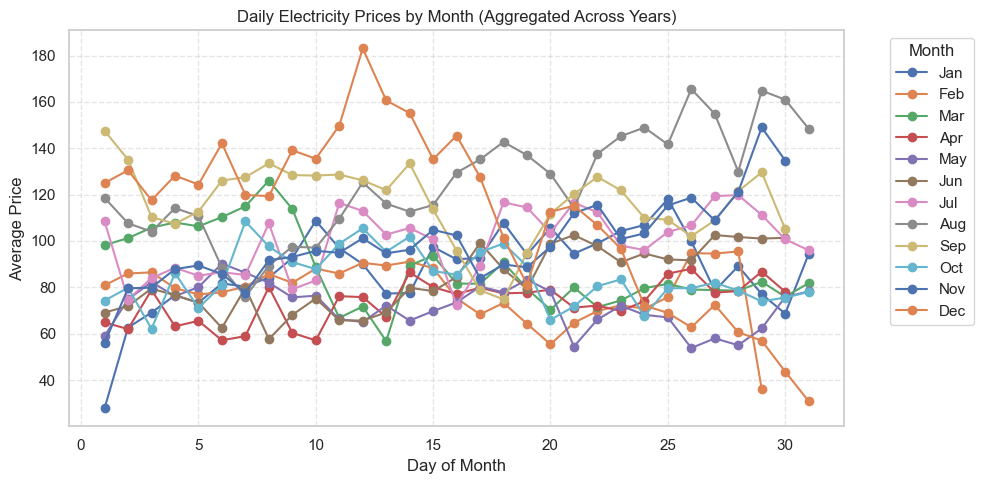

In [37]:
prices_monthly = df_prices.copy()
prices_monthly["month"] = prices_monthly.index.month
prices_monthly["day"] = prices_monthly.index.day

monthly_avg = prices_monthly.groupby(["month", "day"])["Price"].mean().reset_index()
monthly_pivot = monthly_avg.pivot(index="day", columns="month", values="Price")

plt.figure(figsize=(10,5))
month_labels = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
for month in monthly_pivot.columns:
    plt.plot(monthly_pivot.index, monthly_pivot[month], marker='o', label=month_labels[month-1])

sns.set_theme(style="whitegrid")
plt.xlabel('Day of Month')
plt.ylabel('Average Price')
plt.title('Daily Electricity Prices by Month (Aggregated Across Years)')
plt.legend(title='Month', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
#plt.savefig("C:/Users/Startklar/Downloads/Day Ahead Prices By Month.png", dpi=300)
plt.show()

In [97]:
# ADF Test
result_adf = adfuller(df_prices)
print("ADF Statistic:", result_adf[0])
print("p-value:", result_adf[1])
print("Used lags:", result_adf[2])
print("Number of observations:", result_adf[3])

for key, value in result_adf[4].items():
    print(f"Critical Value ({key}): {value}")

ADF Statistic: -8.689993333926825
p-value: 4.0650473380836775e-14
Used lags: 60
Number of observations: 62430
Critical Value (1%): -3.4304547504228338
Critical Value (5%): -2.8615862977387514
Critical Value (10%): -2.5667946427197563


### Predictor Variables

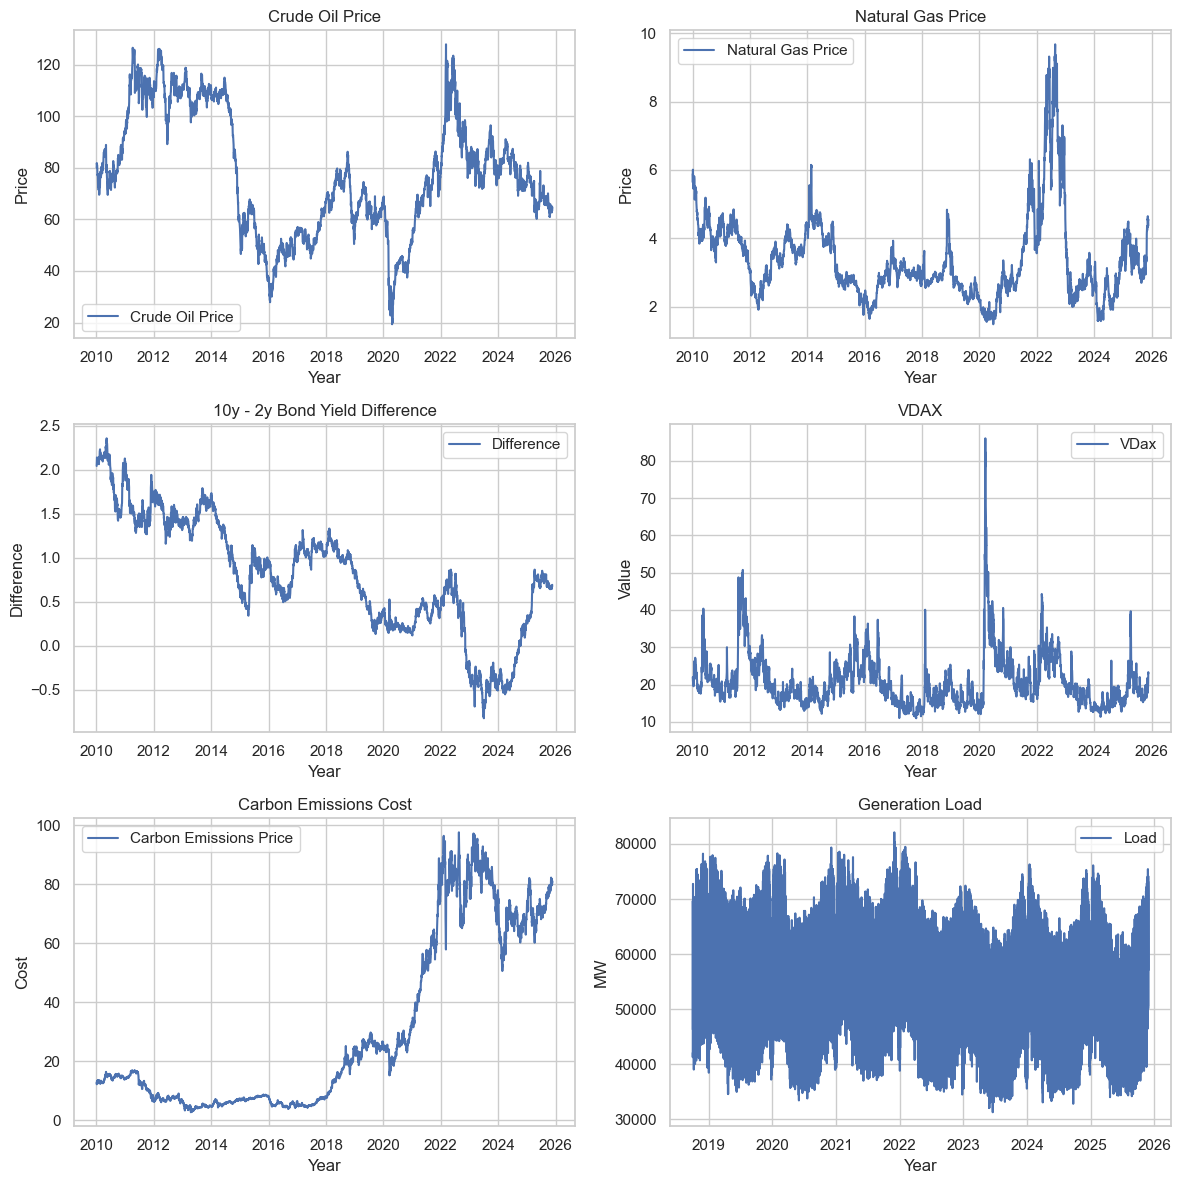

In [98]:
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(3, 2, figsize=(12, 12))

# Plot 1 — Crude Oil
sns.lineplot(ax=ax[0, 0], data=crude_oil)
ax[0, 0].set_title("Crude Oil Price")
ax[0, 0].set_xlabel("Year")
ax[0, 0].set_ylabel("Price")

# Plot 2 — Natural Gas
sns.lineplot(ax=ax[0, 1], data=natural_gas)
ax[0, 1].set_title("Natural Gas Price")
ax[0, 1].set_xlabel("Year")
ax[0, 1].set_ylabel("Price")

# Plot 3 — Bond Yield Diff
sns.lineplot(ax=ax[1, 0], data=bond_yield_difference)
ax[1, 0].set_title("10y - 2y Bond Yield Difference")
ax[1, 0].set_xlabel("Year")
ax[1, 0].set_ylabel("Difference")

# Plot 4 — VDAX
sns.lineplot(ax=ax[1, 1], data=vdax)
ax[1, 1].set_title("VDAX")
ax[1, 1].set_xlabel("Year")
ax[1, 1].set_ylabel("Value")

# Plot 5 — Carbon Emissions
sns.lineplot(ax=ax[2, 0], data=carbon_emissions)
ax[2, 0].set_title("Carbon Emissions Cost")
ax[2, 0].set_xlabel("Year")
ax[2, 0].set_ylabel("Cost")

sns.lineplot(ax=ax[2, 1], data=df_load)
ax[2, 1].set_title("Generation Load")
ax[2, 1].set_xlabel("Year")
ax[2, 1].set_ylabel("MW")

plt.tight_layout()
plt.show()

In [ ]:
# ADF Test on all predictors
def adf_test_series(series):
    result = adfuller(series.dropna())
    return pd.Series({
        "ADF Statistic": result[0],
        "p-value": result[1],
        "# Lags used": result[2],
        "Observations": result[3],
        "Stationary?": "Yes" if result[1]<0.05 else "No"
    })

adf_results = df_data_final.apply(adf_test_series)

adf_results = adf_results.T
print(adf_results)

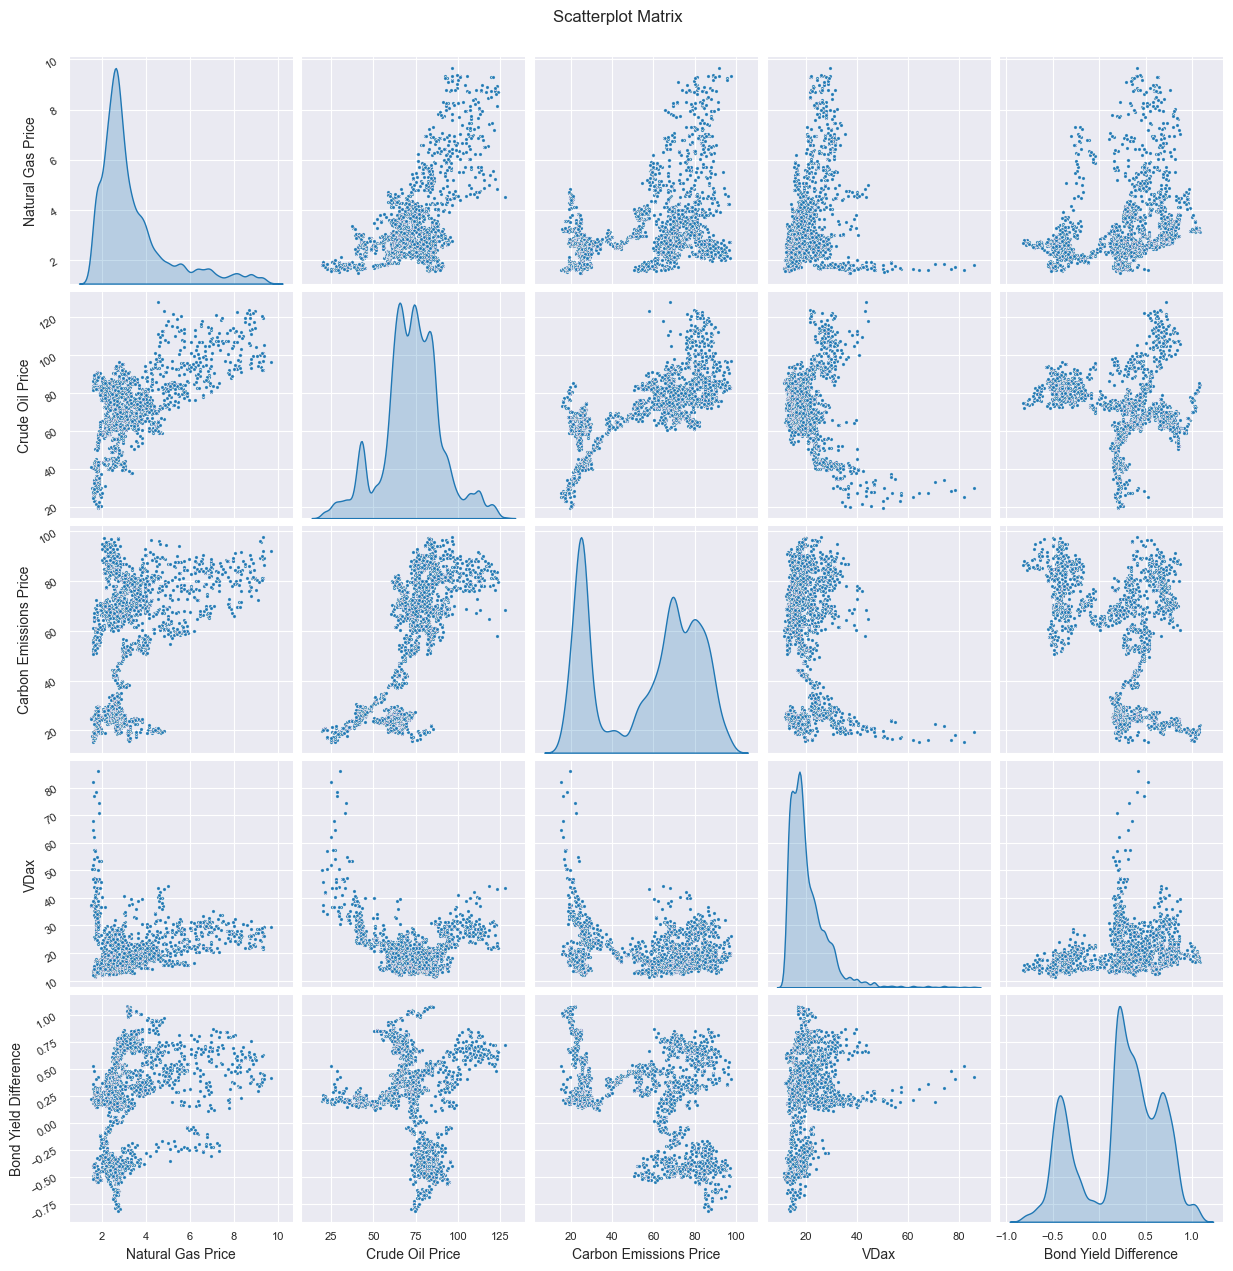

In [59]:
# scatterplot matrix
selected_cols = ["Natural Gas Price", "Crude Oil Price", "Carbon Emissions Price", "VDax", "Bond Yield Difference"]

g = sns.pairplot(df_data_final[selected_cols],
                 diag_kind="kde",
                 plot_kws={"s": 5, "alpha": 0.5})  # s = marker size, alpha = transparency

# Rotate y-axis tick labels
for ax in g.axes.flatten():
    ax.tick_params(axis="y", labelrotation=30, labelsize=8)  # rotate y-axis labels
    ax.tick_params(axis="x", labelsize=8)  # optionally reduce x-axis font size

plt.suptitle("Scatterplot Matrix", fontsize=12, y=1.02)
#plt.savefig("C:/Users/Startklar/OneDrive - Universitaet St.Gallen/DSF Project/Figures/Scatterplot_Matrix.png", dpi=300, bbox_inches="tight")
plt.show()

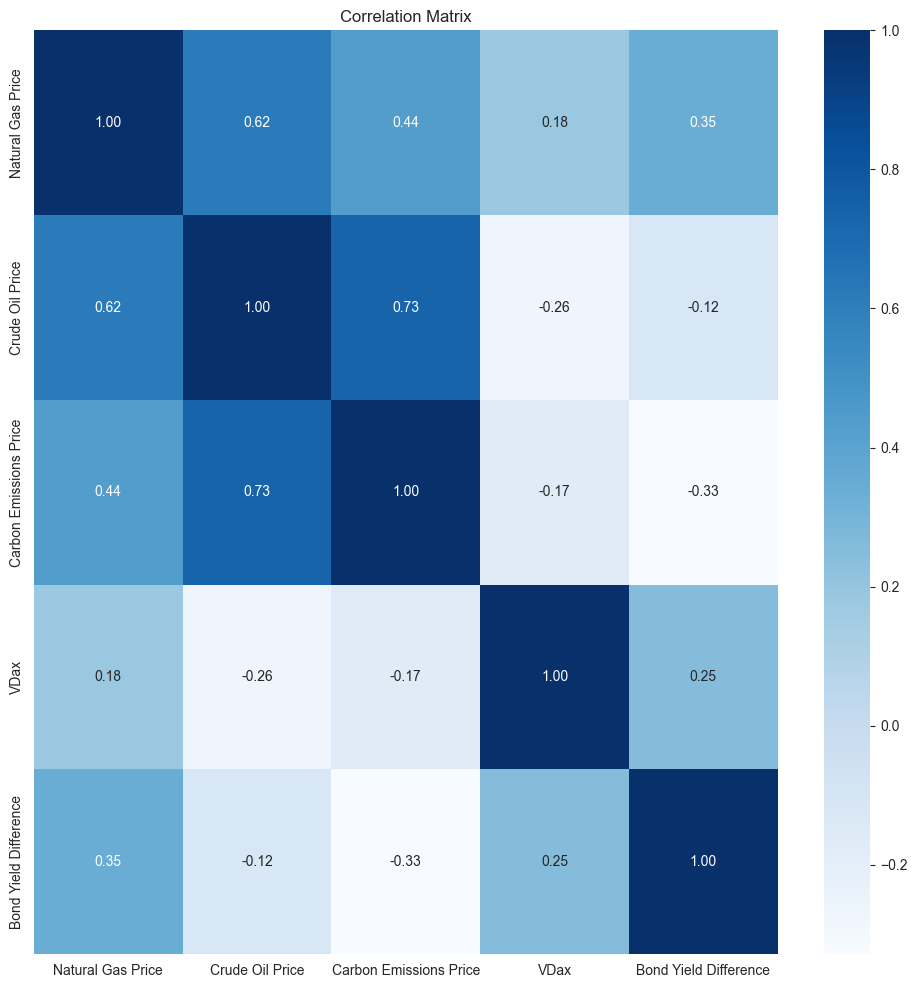

In [60]:
# Correlation matrix
corr = df_data_final[selected_cols].corr()
plt.figure(figsize=(12,12))
sns.heatmap(corr, annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Matrix")
plt.xticks(rotation=0)
plt.yticks(rotation=90)
plt.show()

In [ ]:
# Differencing of non-stationary features
df_data_diff = df_data_final.copy()
non_stationary = ["Natural Gas Price", "Crude Oil Price","Carbon Emissions Price", "Bond Yield Difference"]
for col in non_stationary:
    df_data_diff[col] = df_data_final[col].diff()

df_data_diff = df_data_diff.dropna() #drop first na row

In [ ]:
# Check now differenced columns
adf_results = df_data_diff[non_stationary].apply(adf_test_series)
adf_results = adf_results.T
print(adf_results)

# Train - Test Split

In [35]:
def chronological_train_test_split_df(df, target_col, test_ratio=0.2):

    first_valid = df.index[0].ceil("D") + pd.Timedelta(hours=1)
    last_valid = df.index[-1].floor("D") + pd.Timedelta(hours=0)
    df = df.loc[first_valid:last_valid]

    # Calculate the full days
    n_days = len(df) // 24
    test_days = int(n_days * test_ratio)
    train_days = n_days - test_days

    split_idx = train_days * 24 # where its split

    train_df = df.iloc[:split_idx]
    test_df  = df.iloc[split_idx:]

    X_train = train_df.drop(columns=[target_col])
    y_train = train_df[target_col]

    X_test = test_df.drop(columns=[target_col])
    y_test = test_df[target_col]

    return X_train, y_train, X_test, y_test

In [36]:
# rolling window for cross validation
def rolling_cv_series(df_train, train_size, test_size, step):
    splits = []
    start = 0
    n = len(df_train)

    while start + train_size + test_size <= n:
        train = df_train.iloc[start : start + train_size]
        test = df_train.iloc[start + train_size : start + train_size + test_size]
        splits.append((train, test))
        start += step # move window

    return splits

In [ ]:
X_train, y_train, X_test, y_test = chronological_train_test_split_df(df_data_diff, target_col = "Price", test_ratio=0.2)

y_train = y_train.asfreq("h").ffill()
y_test = y_test.asfreq("h").ffill()
X_train = X_train.asfreq("h").ffill()
X_test = X_test.asfreq("h").ffill()

In [ ]:
print(len(X_test), "hours in test set")
print(len(X_train), "hours in train set")
print(X_train.index.min(), X_train.index.max())
print(X_test.index.min(), X_test.index.max())

# Naive Forecasts (Benchmarks)

### First Benchmark: Predict yesterday's prices

In [ ]:
splits = rolling_cv_series(y_train, train_size=24*30, test_size=24, step=24)

In [ ]:
# Evaluation on training data
mae_list = []
mse_list = []
rmse_list = []

for train_fold, test_fold in splits:

    # naive = last 24 hours of train
    naive_pred = train_fold.tail(24).values

    # true values
    true_vals  = test_fold.values

    mae_list.append(mean_absolute_error(true_vals, naive_pred))
    mse = mean_squared_error(true_vals, naive_pred)
    mse_list.append(mse)
    rmse_list.append(np.sqrt(mse))

print("Naive 1: Last 24 hours - Training performance")
print("MAE :", np.mean(mae_list))
print("MSE :", np.mean(mse_list))
print("RMSE:", np.mean(rmse_list))

In [ ]:
# Start history with the training data (prices before test data)
X_train, y_train, X_test, y_test = chronological_train_test_split_df(df_data_diff, target_col = "Price", test_ratio=0.2)

y_train = y_train.asfreq("h").ffill()
y_test = y_test.asfreq("h").ffill()
X_train = X_train.asfreq("h").ffill()
X_test = X_test.asfreq("h").ffill()

history = y_train.copy()

mae_list = []
mse_list = []
rmse_list = []

# Generate rolling 24-hour blocks over the test set
test_splits = rolling_cv_series(y_test, train_size=0, test_size=24, step=24) # just generates 24h test blocks, no train data needed as we have the history

for _, test_fold in test_splits: # _ means we ignore the train part of the tuple, as its zero anyways

    # Naive forecast: last 24 observed values from history
    naive_pred = history.tail(24).values
    true_vals = test_fold.copy()

    # Compute metrics
    mae_list.append(mean_absolute_error(true_vals, naive_pred))
    mse = mean_squared_error(true_vals, naive_pred)
    mse_list.append(mse)
    rmse_list.append(np.sqrt(mse))

    # Append current fold to history
    history = pd.concat([history, true_vals])

print("Naive 1: Last 24 hours — Test set rolling evaluation")
print("MAE :", np.mean(mae_list))
print("MSE :", np.mean(mse_list))
print("RMSE:", np.mean(rmse_list))

### Second Benchmark: Predict average of prices in all past years

In [ ]:
X_train, y_train, X_test, y_test = chronological_train_test_split_df(df_data_diff, target_col = "Price", test_ratio=0.2)

y_train = y_train.asfreq("h").ffill()
y_test = y_test.asfreq("h").ffill()
X_train = X_train.asfreq("h").ffill()
X_test = X_test.asfreq("h").ffill()

train_df = X_train.copy()
train_df["Price"] = y_train.values #had to do a bit of a workaround here as prices were in y_train

splits = rolling_cv_series(train_df, train_size=24*30, test_size=24, step=24)

In [ ]:
mae_list = []
mse_list = []
rmse_list = []

seasonal_means = train_df.groupby(["day_of_year", "hour"])["Price"].mean()

for i, (_, test_fold) in enumerate(splits, 1):
    forecast_values = []

    for ts in test_fold.index:
        key = (ts.dayofyear, ts.hour)
        val = seasonal_means.get(key)  # fallback if not in precomputed
        forecast_values.append(val)

    seasonal_naive_pred = np.array(forecast_values)
    true_vals = test_fold["Price"].values

    mae_list.append(mean_absolute_error(true_vals, seasonal_naive_pred))
    mse_list.append(mean_squared_error(true_vals, seasonal_naive_pred))
    rmse_list.append(np.sqrt(mean_squared_error(true_vals, seasonal_naive_pred)))

print("Seasonal-Naive Rolling CV")
print("MAE :", np.mean(mae_list))
print("MSE :", np.mean(mse_list))
print("RMSE:", np.mean(rmse_list))

In [ ]:
X_train, y_train, X_test, y_test = chronological_train_test_split_df(df_data_diff, target_col = "Price", test_ratio=0.2)

y_train = y_train.asfreq("h").ffill()
y_test = y_test.asfreq("h").ffill()
X_train = X_train.asfreq("h").ffill()
X_test = X_test.asfreq("h").ffill()

# Combine X_train and y_train into a single DataFrame
history = X_train.copy()
history["Price"] = y_train.values

mae_list = []
mse_list = []
rmse_list = []

# Rolling 24-hour blocks over the test set
test_splits = rolling_cv_series(X_test.copy(), train_size=0, test_size=24, step=24)

for _, test_fold in test_splits:

    # Combine test_fold features with true Price for computation
    test_block = test_fold.copy()
    test_block["Price"] = y_test[test_fold.index].values

    # Compute seasonal means from history
    seasonal_means = history.groupby(["day_of_year", "hour"])["Price"].mean()

    # Forecast each timestamp in the test fold
    forecast_values = []
    for ts in test_block.index:
        key = (ts.dayofyear, ts.hour)
        val = seasonal_means.get(key)
        forecast_values.append(val)

    seasonal_naive_pred = np.array(forecast_values)
    true_vals = test_block["Price"].values

    mae_list.append(mean_absolute_error(true_vals, seasonal_naive_pred))
    mse = mean_squared_error(true_vals, seasonal_naive_pred)
    mse_list.append(mse)
    rmse_list.append(np.sqrt(mse))

    # Appends current fold to history
    history = pd.concat([history, test_block])

print("Naive 2: Seasonal Means - Test set rolling evaluation")
print("MAE :", np.mean(mae_list))
print("MSE :", np.mean(mse_list))
print("RMSE:", np.mean(rmse_list))

# Regression models
---

### Simple OLS regression

In [ ]:
X_train, y_train, X_test, y_test = chronological_train_test_split_df(df_data_diff, target_col = "Price", test_ratio=0.2)

y_train = y_train.asfreq("h").ffill()
y_test = y_test.asfreq("h").ffill()
X_train = X_train.asfreq("h").ffill()
X_test = X_test.asfreq("h").ffill()

train_df = X_train.copy()
train_df["Price"] = y_train.values # same workaround as earlier

splits = rolling_cv_series(train_df, train_size=24*365, test_size=24, step=24) # Training at least on one full year, and usual 24h test windows

In [ ]:
mae_list = []
mse_list = []
rmse_list = []

for i, (train_fold, test_fold) in enumerate(splits):
    X_train = train_fold.drop(columns="Price")
    y_train = train_fold["Price"]

    X_test = test_fold.drop(columns="Price")
    y_test = test_fold["Price"]

    model = LinearRegression()
    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae_list.append(mean_absolute_error(y_test, pred))
    mse_list.append(mean_squared_error(y_test, pred))
    rmse_list.append(np.sqrt(mean_squared_error(y_test, pred)))


print("Regression Model: Training results")
print("MAE :", np.mean(mae_list))
print("MSE :", np.mean(mse_list))
print("RMSE:", np.mean(rmse_list))

In [ ]:
X_train, y_train, X_test, y_test = chronological_train_test_split_df(df_data_diff, target_col = "Price", test_ratio=0.2)

y_train = y_train.asfreq("h").ffill()
y_test = y_test.asfreq("h").ffill()
X_train = X_train.asfreq("h").ffill()
X_test = X_test.asfreq("h").ffill()

# Test set evaluation
history = X_train.copy()
history["Price"] = y_train.values

mae_list = []
mse_list = []
rmse_list = []

# Generate rolling 24-hour test blocks
test_splits = rolling_cv_series(X_test.copy(), train_size=0, test_size=24, step=24)

for _, test_fold in test_splits:

    # Combine test features with true Price for metrics
    test_block = test_fold.copy()
    test_block["Price"] = y_test[test_fold.index].values

    # Split features and target
    X_test_block = test_block.drop(columns="Price")
    y_test_block = test_block["Price"]

    # Train model on full history
    X_history = history.drop(columns="Price")
    y_history = history["Price"]

    model = LinearRegression()
    model.fit(X_history, y_history)

    # Make predictions
    pred = model.predict(X_test_block)

    # Metrics
    mae_list.append(mean_absolute_error(y_test_block, pred))
    mse = mean_squared_error(y_test_block, pred)
    mse_list.append(mse)
    rmse_list.append(np.sqrt(mse))

    # Append current test block to history
    history = pd.concat([history, test_block])

print("Regression Model: Test set evaluation")
print("MAE :", np.mean(mae_list))
print("MSE :", np.mean(mse_list))
print("RMSE:", np.mean(rmse_list))

### LASSO regression

In [ ]:
alphas = [0.001, 0.01, 0.1, 1, 10]

In [ ]:
X_train, y_train, X_test, y_test = chronological_train_test_split_df(df_data_diff, target_col = "Price", test_ratio=0.2)

y_train = y_train.asfreq("h").ffill()
y_test = y_test.asfreq("h").ffill()
X_train = X_train.asfreq("h").ffill()
X_test = X_test.asfreq("h").ffill()

train_df = X_train.copy()
train_df["Price"] = y_train.values
splits = rolling_cv_series(train_df, train_size=24*365, test_size=24, step=24*30)

In [ ]:
print(len(train_df))
print(len(splits))
best_alpha = None
best_rmse = np.inf

for alpha in alphas:
    rmse_list = []

    for i, (train_fold, test_fold) in enumerate(splits, 1):  # enumerate adds i
        X_train = train_fold.drop(columns="Price")
        y_train = train_fold["Price"]

        X_test = test_fold.drop(columns="Price")
        y_test = test_fold["Price"]

        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Lasso with current alpha
        model = Lasso(alpha=alpha, max_iter=10000)
        model.fit(X_train_scaled, y_train)

        pred = model.predict(X_test_scaled)
        rmse_list.append(np.sqrt(mean_squared_error(y_test, pred)))

    mean_rmse = np.mean(rmse_list)
    print(f"\nAlpha={alpha}, mean RMSE={mean_rmse:.4f}")  # new line after all folds

    if mean_rmse < best_rmse:
        best_rmse = mean_rmse
        best_alpha = alpha

print(f"\nBest alpha: {best_alpha} with RMSE={best_rmse:.4f}")

In [126]:
X_train, y_train, X_test, y_test = chronological_train_test_split_df(df_data_diff, target_col = "Price", test_ratio=0.2)

y_train = y_train.asfreq("h").ffill()
y_test = y_test.asfreq("h").ffill()
X_train = X_train.asfreq("h").ffill()
X_test = X_test.asfreq("h").ffill()

In [ ]:
history = X_train.copy()
history["Price"] = y_train.values

mae_list = []
mse_list = []
rmse_list = []

test_splits = rolling_cv_series(X_test.copy(), train_size=0, test_size=24, step=24)

for _, test_fold in test_splits:
    test_block = test_fold.copy()
    test_block["Price"] = y_test[test_fold.index].values

    # Split features and target
    X_test_block = test_block.drop(columns="Price")
    y_test_block = test_block["Price"]

    # Train on full history
    X_history = history.drop(columns="Price")
    y_history = history["Price"]

    scaler = StandardScaler()
    X_history_scaled = scaler.fit_transform(X_history)
    X_test_scaled = scaler.transform(X_test_block)

    model = Lasso(alpha=best_alpha, max_iter=10000)
    model.fit(X_history_scaled, y_history)

    pred = model.predict(X_test_scaled)

    mae_list.append(mean_absolute_error(y_test_block, pred))
    mse = mean_squared_error(y_test_block, pred)
    mse_list.append(mse)
    rmse_list.append(np.sqrt(mse))

    # append block to history
    history = pd.concat([history, test_block])

print("LASSO Regression: Test set evaluation")
print(f"Best alpha: {best_alpha}")
print("MAE :", np.mean(mae_list))
print("MSE :", np.mean(mse_list))
print("RMSE:", np.mean(rmse_list))

# ARIMA Models
___
Steps:
- Simple ARMA model without differencing
- ADF test
- Differencing (using 24h)
- Displaying PACF and ACF
- ARIMA model with differenced data

### ACF & PACF Plots

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(10,5))

plot_acf(df_data_diff["Price"], lags = 100, ax = ax[0])
plot_pacf(df_data_diff["Price"], lags = 100, ax = ax[1])

ax[0].set_title("ACF")
ax[1].set_title("PACF")

### ARIMA model

In [ ]:
# Again redefining just in case
X_train, y_train, X_test, y_test = chronological_train_test_split_df(df_data_diff, target_col = "Price", test_ratio=0.2)
#fine for naive forecast because Price is not differenced, only predictors

y_train = y_train.asfreq("h").ffill()
y_test = y_test.asfreq("h").ffill()
X_train = X_train.asfreq("h").ffill()
X_test = X_test.asfreq("h").ffill()

In [ ]:
train_df = X_train.copy()
train_df["Price"] = y_train.values
splits = rolling_cv_series(train_df, train_size=24*365, test_size=24, step=24*90) # Increased step size for ARIMA models to reduce training time

In [ ]:
p_values = [1, 2, 3]
d_values = [0, 1, 2]
q_values = [1, 2, 3]

best_rmse = float("inf")
best_order = None

total_combinations = len(p_values) * len(d_values) * len(q_values)
comb_index = 0

for p in p_values:
    for d in d_values:
        for q in q_values:
            comb_index += 1
            print(f"Evaluating combination {comb_index}/{total_combinations}: p={p}, d={d}, q={q}")

            rmse_list = []

            for fold_idx, (train_fold, test_fold) in enumerate(splits, 1):
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    warnings.simplefilter("ignore", ConvergenceWarning)

                    model = ARIMA(train_fold["Price"], order=(p, d, q))
                    res = model.fit()
                    forecast = res.get_forecast(steps=len(test_fold)).predicted_mean

                true_vals = test_fold["Price"].values
                rmse_list.append(np.sqrt(mean_squared_error(true_vals, forecast)))

            mean_rmse = np.mean(rmse_list)
            print(f"  Mean RMSE for this combination: {mean_rmse:.4f}")

            if mean_rmse < best_rmse:
                best_rmse = mean_rmse
                best_order = (p, d, q)

print("Best ARIMA order:", best_order, "with RMSE:", best_rmse)
# Results: (1, 1, 3) with RMSE of 42.61

In [ ]:
X_train, y_train, X_test, y_test = chronological_train_test_split_df(df_data_diff, target_col = "Price", test_ratio=0.2)
#fine for naive forecast because Price is not differenced, only predictors

y_train = y_train.asfreq("h").ffill()
y_test = y_test.asfreq("h").ffill()
X_train = X_train.asfreq("h").ffill()
X_test = X_test.asfreq("h").ffill()

train_window = 24*90
test_size = 24
step = 24
best_order = (1, 1, 3)

history = y_train.copy()  # pandas Series with datetime index

# Generate rolling test splits (train_size can be 0, it's ignored in test evaluation)
test_splits = rolling_cv_series(y_test.to_frame("Price"), train_size=0, test_size=test_size, step=step)

mae_list = []
mse_list = []
rmse_list = []

for i, (_, test_block) in enumerate(test_splits, 1):
    y_test_block = test_block["Price"].ffill()  # handle any NaNs
    y_train_window = history.iloc[-train_window:]

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model = ARIMA(
            y_train_window,
            order=best_order
        )
        res = model.fit()

    forecast = res.get_forecast(steps=len(y_test_block)).predicted_mean

    mae_list.append(mean_absolute_error(y_test_block, forecast))
    mse_list.append(mean_squared_error(y_test_block, forecast))
    rmse_list.append(np.sqrt(mean_squared_error(y_test_block, forecast)))

    history = pd.concat([history, y_test_block])
    if i % 10 == 0:
        print(f"Processed block {i}/{len(test_splits)}")

print("ARIMA Rolling-Window Test Set Evaluation")
print(f"MAE:  {np.mean(mae_list):.4f}")
print(f"MSE:  {np.mean(mse_list):.4f}")
print(f"RMSE: {np.mean(rmse_list):.4f}")

### SARIMA model

In [ ]:
X_train, y_train, X_test, y_test = chronological_train_test_split_df(df_data_diff, target_col = "Price", test_ratio=0.2)
#fine for naive forecast because Price is not differenced, only predictors

y_train = y_train.asfreq("h").ffill()
y_test = y_test.asfreq("h").ffill()
X_train = X_train.asfreq("h").ffill()
X_test = X_test.asfreq("h").ffill()

train_df = X_train.copy()
train_df["Price"] = y_train.values
splits = rolling_cv_series(train_df, train_size=24*365, test_size=24, step=24*90) # Same here, one year of training data to pick up on long-etrm patterns but 3 mo step size

In [ ]:
seasonal_orders = [(P, D, Q, 24) for P in [0,1,2] for D in [0,1] for Q in [0,1]]
seasonal_orders
# P is the nr of seasonal AR terms, just trying 0, 1 or 2 here. D is the number of differences to apply. Q is the number of seasonal moving average terms. Only trying 0 or 1 to speed up computations.

In [ ]:
mae_list = []
mse_list = []
rmse_list = []

total_combinations = len(seasonal_orders)
comb_index = 0

best_rmse = np.inf
best_seasonal = None

# Convert training data to DataFrame for rolling CV
train_df = pd.DataFrame({"Price": y_train})


splits = rolling_cv_series(train_df, train_size=24*30, test_size=24, step=24*30) # Monthly train windows and monthly steps to reduce training time


for seasonal in seasonal_orders:
    comb_index += 1
    print(f"\nEvaluating combination {comb_index}/{total_combinations}: seasonal_order={seasonal}")

    rmse_list = []

    for fold_idx, (train_fold, test_fold) in enumerate(splits, 1):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=ValueWarning)
            warnings.simplefilter("ignore", category=ConvergenceWarning)

            model = SARIMAX(
                train_fold["Price"],
                order=(1, 1, 3),
                seasonal_order=seasonal,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            res = model.fit(disp=False)

        forecast = res.get_forecast(steps=len(test_fold)).predicted_mean
        rmse_list.append(np.sqrt(mean_squared_error(test_fold["Price"], forecast)))

        # Print progress every 5 folds
        if fold_idx % 5 == 0:
            print(f"  Fold {fold_idx}/{len(splits)} processed")

    mean_rmse = np.mean(rmse_list)
    print(f"  Mean RMSE for this seasonal order: {mean_rmse:.4f}")

    if mean_rmse < best_rmse:
        best_rmse = mean_rmse
        best_seasonal = seasonal

print("\nBest seasonal order:", best_seasonal, "with RMSE:", best_rmse)
# Obtained result: (1, 0, 1, 24) with RMSE of 21.95

In [ ]:
X_train, y_train, X_test, y_test = chronological_train_test_split_df(df_data_diff, target_col = "Price", test_ratio=0.2)

y_train = y_train.asfreq("h").ffill()
y_test = y_test.asfreq("h").ffill()
X_train = X_train.asfreq("h").ffill()
X_test = X_test.asfreq("h").ffill()

train_df = X_train.copy()
train_df["Price"] = y_train.values

train_window = 24*90  # 1 year
test_size = 24         # 24-hour forecast
step = 24              # move window by 1 day
best_order = (1, 1, 3)         # from ARIMA CV
best_seasonal = (1, 0, 1, 24)

history = train_df.copy()       # full training set with "Price" column
test_df = y_test.to_frame("Price")

mae_list = []
mse_list = []
rmse_list = []

num_folds = 50
rows_needed = test_size * (num_folds - 1) + test_size
sparse_test_df = test_df.iloc[:rows_needed]

# Generate rolling 24-hour test blocks
test_splits = rolling_cv_series(sparse_test_df, train_size=0, test_size=test_size, step=step)
total_folds = len(test_splits)

for i, (_, test_block) in enumerate(test_splits, 1):
    y_test_block = test_block["Price"].ffill()  # handle NaNs

    # take the last 1 year of data for training
    y_train_window = history["Price"].iloc[-train_window:]

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model = SARIMAX(
            y_train_window,
            order=best_order,
            seasonal_order=best_seasonal,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        res = model.fit(disp=False)

        # forecast the next 24 hours
        forecast = res.get_forecast(steps=len(y_test_block)).predicted_mean

    # compute metrics
    mae_list.append(mean_absolute_error(y_test_block, forecast))
    mse_list.append(mean_squared_error(y_test_block, forecast))
    rmse_list.append(np.sqrt(mean_squared_error(y_test_block, forecast)))

    # append actual observed block to history
    history = pd.concat([history, test_block])

    if i % 10 == 0:
        print(f"Processed {i}/{total_folds} test blocks")

# final metrics
print("\nSARIMA Test Set Evaluation")
print(f"MAE:  {np.mean(mae_list):.4f}")
print(f"MSE:  {np.mean(mse_list):.4f}")
print(f"RMSE: {np.mean(rmse_list):.4f}")

### SARIMAX (SARIMA with exogenous variables)

In [95]:
exogenous = ['BiomassActual Aggregated',
       'Fossil Brown coal/LigniteActual Aggregated',
       'Fossil GasActual Aggregated', 'Fossil Hard coalActual Aggregated',
       'Fossil OilActual Aggregated', 'GeothermalActual Aggregated',
       'Hydro Run-of-river and poundageActual Aggregated',
       'Hydro Water ReservoirActual Aggregated', 'OtherActual Aggregated',
       'Other renewableActual Aggregated', 'SolarActual Aggregated',
       'WasteActual Aggregated', 'Wind OffshoreActual Aggregated',
       'Wind OnshoreActual Aggregated', 'Hydro Pumped Storage Net',
       'Natural Gas Price', 'Crude Oil Price', 'Carbon Emissions Price',
       'Bond Yield Difference', 'VDax']

In [ ]:
X_train, y_train, X_test, y_test = chronological_train_test_split_df(df_data_diff, target_col = "Price", test_ratio=0.2)

y_train = y_train.asfreq("h").ffill()
y_test = y_test.asfreq("h").ffill()
X_train = X_train.asfreq("h").ffill()
X_test = X_test.asfreq("h").ffill()

# performance on training data, not necessarily needed
train_df = X_train.copy()
train_df["Price"] = y_train.values

order = (3, 1, 2)
seasonal_order = (1, 0, 1, 24)

train_size = 24*90
splits = rolling_cv_series(train_df, train_size=24*90, test_size=24, step=24)

mae_list = []
mse_list = []
rmse_list = []

total_folds = len(splits)

for i, (train_fold, test_fold) in enumerate(splits, 1):
    y_train_window = train_fold["Price"].iloc[-train_size:]
    exog_train_window = train_fold[exogenous].iloc[-train_size:].ffill()

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", ConvergenceWarning)
        model = SARIMAX(
            endog=y_train_window,
            exog=exog_train_window,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        res = model.fit(disp=False)

    forecast = res.get_forecast(
        steps=len(test_fold),
        exog=test_fold[exogenous]
    ).predicted_mean

    true_vals = test_fold["Price"].values
    mae_list.append(mean_absolute_error(true_vals, forecast))
    mse_list.append(mean_squared_error(true_vals, forecast))
    rmse_list.append(np.sqrt(mean_squared_error(true_vals, forecast)))
    if i % 1 == 0:
        print(f"Processing fold {i}/{total_folds}")

print("\nRolling 1-Year SARIMAX Evaluation Complete")
print("Average MAE:", np.mean(mae_list))
print("Average MSE:", np.mean(mse_list))
print("Average RMSE:", np.mean(rmse_list))

In [96]:
# Parameters
train_window = 24*365  # 1 year
test_size = 24         # 24-hour forecast
step = 24              # move window by 1 day

history = train_df.copy().ffill()

mae_list = []
mse_list = []
rmse_list = []

test_df = X_test.copy()
test_df["Price"] = y_test.values

num_folds = 50
rows_needed = test_size * (num_folds - 1) + test_size
sparse_test_df = test_df.iloc[:rows_needed]

# Generate rolling 24-hour test blocks
test_splits = rolling_cv_series(sparse_test_df, train_size=0, test_size=test_size, step=step)
total_folds = len(test_splits)

for i, (_, test_block) in enumerate(test_splits, 1):
    y_test_block = test_block["Price"]
    X_test_block = test_block[exogenous]  # exogenous columns

    # Use only the last 1-year of data as training
    y_train_window = history["Price"].iloc[-train_window:]
    X_train_window = history[exogenous].iloc[-train_window:]

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        warnings.simplefilter("ignore", ConvergenceWarning)

        # Fit SARIMAX on rolling 1-year window
        model = SARIMAX(
            endog=y_train_window,
            exog=X_train_window,
            order=(2, 0, 2),
            seasonal_order=(0, 1, 0, 24),
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        res = model.fit(disp=False)

    # Forecast next block
    forecast = res.get_forecast(steps=len(y_test_block), exog=X_test_block).predicted_mean

    # Compute metrics
    mae_list.append(mean_absolute_error(y_test_block, forecast))
    mse_list.append(mean_squared_error(y_test_block, forecast))
    rmse_list.append(np.sqrt(mean_squared_error(y_test_block, forecast)))

    # Append actual test block to history
    history = pd.concat([history, test_block])
    print(f"Processed fold {i}/{total_folds}")

print("\nSARIMAX Test Set Evaluation")
print("MAE :", np.mean(mae_list))
print("MSE :", np.mean(mse_list))
print("RMSE:", np.mean(rmse_list))

Processed fold 1/50
Processed fold 2/50
Processed fold 3/50
Processed fold 4/50
Processed fold 5/50
Processed fold 6/50
Processed fold 7/50
Processed fold 8/50
Processed fold 9/50
Processed fold 10/50
Processed fold 11/50
Processed fold 12/50
Processed fold 13/50
Processed fold 14/50
Processed fold 15/50
Processed fold 16/50
Processed fold 17/50
Processed fold 18/50
Processed fold 19/50
Processed fold 20/50
Processed fold 21/50
Processed fold 22/50
Processed fold 23/50
Processed fold 24/50
Processed fold 25/50
Processed fold 26/50
Processed fold 27/50
Processed fold 28/50
Processed fold 29/50
Processed fold 30/50
Processed fold 31/50
Processed fold 32/50
Processed fold 33/50
Processed fold 34/50
Processed fold 35/50
Processed fold 36/50
Processed fold 37/50
Processed fold 38/50
Processed fold 39/50
Processed fold 40/50
Processed fold 41/50
Processed fold 42/50
Processed fold 43/50
Processed fold 44/50
Processed fold 45/50
Processed fold 46/50
Processed fold 47/50
Processed fold 48/50
P

# LSTMs

## LSTM hyperparameters optimisation

In [35]:
data = df_data_final_lstm
print(data.shape)
# data = data.drop(data.index[0:2]) # to start at midnight

(62298, 49)


In [ ]:
#### Functions

def scale_data1(X_train, X_val, X_test, target=0):
    y_train = X_train.iloc[:, target].values
    y_val   = X_val.iloc[:, target].values
    y_test  = X_test.iloc[:, target].values


    X_scaler = StandardScaler()
    y_scaler = StandardScaler()

    # Fit on training data only
    X_scaler.fit(X_train)
    y_scaler.fit(y_train.reshape(-1,1))

    # Transform
    X_train_s = X_scaler.transform(X_train)
    X_val_s   = X_scaler.transform(X_val)
    X_test_s  = X_scaler.transform(X_test)

    y_train_s = y_scaler.transform(y_train.reshape(-1,1)).flatten()
    y_val_s   = y_scaler.transform(y_val.reshape(-1,1)).flatten()
    y_test_s  = y_scaler.transform(y_test.reshape(-1,1)).flatten()

    return X_train_s, X_val_s, X_test_s, y_train_s, y_val_s, y_test_s, X_scaler, y_scaler


def create_sequences(data, Y, window, horizon, mode="train"):
    X, y = [], []

    if mode == "train":
        step = 24
    else:
        step = window + horizon

    for i in range(0, len(data) - window - horizon + 1, step):
        X.append(data[i:i+window])
        y.append(Y[i+window:i+window+horizon])

    return np.array(X), np.array(y)

def split_time_series(data, train_ratio=0.7, val_ratio=0.15):
    n = len(data)

    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))

    train = data[:train_end]
    val = data[train_end:val_end]
    test = data[val_end:]

    return train, val, test

def build_model(window, n_features, horizon, lstm_units, dropout_rate, learning_rate):
    model = Sequential()

    # First LSTM layer
    model.add(LSTM(lstm_units[0],
                   return_sequences=(len(lstm_units) > 1),
                   input_shape=(window, n_features)))
    model.add(Dropout(dropout_rate))

    # Additional LSTM layers
    for i, units in enumerate(lstm_units[1:]):
        # Only last LSTM returns_sequences=False
        return_seq = i < len(lstm_units[1:]) - 1
        model.add(LSTM(units, return_sequences=return_seq))
        model.add(Dropout(dropout_rate))

    # Output layer
    model.add(Dense(horizon))

    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mse")
    return model


def train_model(model, X_train, y_train, X_val, y_val, epochs=50, batch_size=32):
    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        verbose=1
    )
    return history

def hyperparameter_search(X_train, y_train, X_val, y_val ,
                          n_features, horizon=24):
    # Hyperparameter grids
    window_list = [168]
    batch_list = [32]
    units_list = [128]
    layers_list = [2]
    dropout_list = [0.15]
    lr_list = [0.001]
 # training: window=168, batch=32, units=256, layers=2, dropout=0.0, lr=0.001
    best_loss = float("inf")
    best_model = None
    best_params = None

    for window in window_list:
        # Create sequences for current window
        X_train_seq, y_train_seq = create_sequences(X_train, y_train, window, horizon)
        X_val_seq, y_val_seq = create_sequences(X_val, y_val, window, horizon)

        for batch_size in batch_list:
            for units in units_list:
                for layers in layers_list:
                    for dropout in dropout_list:
                        for lr in lr_list:

                            lstm_units = [units] * layers

                            model = build_model(
                                window=window,
                                n_features=n_features,
                                horizon=horizon,
                                lstm_units=lstm_units,
                                dropout_rate=dropout,
                                learning_rate=lr
                            )

                            print(f"\nTraining: window={window}, batch={batch_size}, units={units}, layers={layers}, dropout={dropout}, lr={lr}")

                            history = model.fit(
                                X_train_seq, y_train_seq,
                                validation_data=(X_val_seq, y_val_seq),
                                epochs=50,
                                batch_size=batch_size,
                                verbose=1
                            )

                            val_loss = min(history.history["val_loss"])

                            if val_loss < best_loss:
                                best_loss = val_loss
                                best_model = model
                                best_params = {
                                    "window": window,
                                    "batch_size": batch_size,
                                    "units": units,
                                    "layers": layers,
                                    "dropout": dropout,
                                    "learning_rate": lr
                                }

                            print(f"Val loss={val_loss:.6f} | Best={best_loss:.6f}")

    return best_model, best_params, best_loss

In [ ]:
#### Execution
horizon = 24

# 1) Split raw data
train, val, test = split_time_series(data)

# 2) Scale using ONLY train
X_train_s, X_val_s, X_test_s, y_train_s, y_val_s, y_test_s, X_scaler, y_scaler = scale_data1(train, val, test)

# 3) Run hyperparameter search
best_model, best_params, best_loss = hyperparameter_search(
    X_train_s,y_train_s, X_val_s, y_val_s,
    n_features=data.shape[1],
    horizon=horizon
)

print("Best params:", best_params)
#Best params: {'window': 168, 'batch_size': 32, 'units': 128, 'layers': 2, 'dropout': 0.15, 'learning_rate': 0.001}

In [ ]:
#### Evaluation
best_window = best_params["window"]
X_test,  y_test  = create_sequences(X_test_s,y_test_s, best_window, horizon, mode="test")

y_pred = best_model.predict(X_test)  # shape: (num_test_sequences, horizon)
# Inverse transform
y_pred_real = y_scaler.inverse_transform(y_pred.reshape(-1, 1)).reshape(y_pred.shape)
y_test_real = y_scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(y_test.shape)


mse  = np.mean((y_test_real - y_pred_real)**2)
rmse = np.sqrt(mse)
mae  = np.mean(np.abs(y_test_real - y_pred_real))

print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE:  {mae:.4f}")
#MSE:  4046.1498
#RMSE: 63.6094
#MAE:  51.3312

# Random Forest
___
Time Series Split (links for easy access – will remove later)
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html
- https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html


### MultiOutputRegressor Random Forest – model that can predict a vector of 24h
- We are using independent random forests for each hour in the day
- https://scikit-learn.org/stable/modules/generated/sklearn.multioutput.MultiOutputRegressor.html

In [37]:
def chronological_split_daily(X, y, test_ratio=0.2): #similar to Dorian's code – but for this model we have daily rows
    n_days = len(X)
    test_days = int(n_days * test_ratio)
    train_days = n_days - test_days

    X_train = X.iloc[:train_days]
    y_train = y.iloc[:train_days]

    X_test = X.iloc[train_days:]
    y_test = y.iloc[train_days:]

    return X_train, y_train, X_test, y_test

In [38]:
def create_daily_features(df_data_final):
    df = df_data_final.copy()
    df['Total Wind'] = df['Wind OffshoreActual Aggregated']+ df['Wind OnshoreActual Aggregated']
    df['Residual'] = df['Load'] - df['Total Wind'] - df['SolarActual Aggregated']
    y = df.pivot_table(index=df.index.date, columns=df.index.hour, values='Price')
    y.columns = [f'Price_H{h}' for h in range(24)]
    df['Merit_order_factor'] = df['Residual'] * df['Natural Gas Price'] #possibly works better to explain prices from 16 to 19h, which are the biggest problem right now


    cols_act = ['Lag24', 'Lag48', 'Lag168']
    vec_feats = []

    for col in cols_act:
        f = df.pivot_table(index=df.index.date, columns=df.index.hour, values=col)
        f.columns = [f'{col}_H{h}' for h in range(24)]
        vec_feats.append(f)

    res_piv = df.pivot_table(index=df.index.date, columns=df.index.hour, values='Residual')
    if 16 in res_piv.columns and 19 in res_piv.columns:
        ramp = res_piv[19] - res_piv[16]
        ramp.name = 'Residual_Ramp_Afternoon'
        vec_feats.append(ramp)

    scalar_vars = ['Natural Gas Price', 'Carbon Emissions Price', 'Residual', 'Merit_order_factor']
    for col in scalar_vars:
            s = df[col].resample('D').mean()
            s.index = s.index.date
            s.name = f'{col}_Mean'
            vec_feats.append(s)

    X = pd.concat(vec_feats, axis=1)

    common_idx = X.index.intersection(y.index)
    y = y.loc[common_idx].dropna()
    X = X.loc[common_idx].dropna()
    y = y.loc[X.index]

    return X, y


In [39]:
X_daily, y_daily = create_daily_features(df_data_final)

X_daily.index = pd.to_datetime(X_daily.index)

X_daily['X_Lag24_Mean'] = X_daily[[c for c in X_daily.columns if 'Lag24' in c]].mean(axis=1)
X_daily['Day_sin'] = np.sin(2 * np.pi * X_daily.index.dayofweek / 7)
X_daily

,Lag24_H0,Lag24_H1,Lag24_H2,Lag24_H3,Lag24_H4,Lag24_H5,Lag24_H6,Lag24_H7,Lag24_H8,Lag24_H9,...,Lag168_H21,Lag168_H22,Lag168_H23,Residual_Ramp_Afternoon,Natural Gas Price_Mean,Carbon Emissions Price_Mean,Residual_Mean,Merit_order_factor_Mean,X_Lag24_Mean,Day_sin
2018-10-09,50.1600,47.3200,47.9400,51.1400,62.7900,79.9800,82.4200,81.5800,66.8900,52.0600,...,1.0800,2.1300,0.1000,-282.625000,3.267,21.94,46338.691979,151388.506696,64.230000,0.781831
2018-10-10,55.1100,52.3500,54.8600,57.9900,74.2700,91.3700,96.6800,91.9500,82.5400,64.7000,...,48.7200,53.2400,46.1000,-1000.412500,3.266,20.79,48844.196771,159525.146654,71.341250,0.974928
2018-10-11,54.8800,54.0500,54.6400,55.4600,72.1600,88.0000,93.2200,86.8400,80.8100,73.6900,...,52.2500,49.5700,51.1600,-6985.067500,3.284,19.46,43885.595000,144120.293980,60.417500,0.433884
2018-10-12,29.9700,30.0500,35.8500,44.0800,49.9800,72.9600,71.5200,59.8000,49.2100,48.6100,...,54.7000,50.1000,52.9800,-5213.322500,3.222,19.87,40790.374583,131426.586908,55.393750,-0.433884
2018-10-13,45.6000,45.6400,45.8000,49.6400,56.6500,69.8700,71.4700,69.7100,69.5200,61.9500,...,46.4600,50.4900,47.1100,-9097.180000,3.161,20.37,41241.308646,130363.776629,56.772083,-0.974928
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-11,87.6350,88.9025,87.5225,87.1775,92.3125,113.4525,142.9950,157.8750,144.2975,126.2725,...,86.2375,76.1225,77.3300,-4283.881785,4.338,79.96,48880.461678,212043.442758,109.647188,0.781831
2025-11-12,79.9825,75.8025,74.8700,75.4950,77.0725,86.7875,105.2100,113.7975,103.1150,91.4725,...,88.8475,87.7000,93.3725,-4038.050813,4.565,80.65,38861.423213,177402.396968,96.545104,0.974928
2025-11-13,68.3150,64.4100,62.4000,62.3000,69.3000,76.9975,107.2600,100.7225,78.1125,71.5275,...,97.4850,90.5525,90.1775,-3378.699355,4.533,81.91,29417.644853,133350.184118,78.571250,0.433884
2025-11-14,18.9725,11.1875,7.7800,6.0000,25.9725,50.8850,76.8450,66.0825,53.6100,50.3225,...,98.2750,92.0525,96.5300,6714.769538,4.646,81.34,27587.965507,128173.687746,72.576458,-0.433884


In [40]:
X_daily_train, y_daily_train, X_daily_holdout, y_daily_holdout = chronological_split_daily(X_daily, y_daily, test_ratio=0.2)

print(f'Train shapes: {X_daily_train.shape}')
print(f'Holdout shapes: {X_daily_holdout.shape}')

Train shapes: (2071, 79)
Holdout shapes: (517, 79)


In [41]:
tscv = TimeSeriesSplit(n_splits = 5)

In [42]:
param_dist_n1 = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 6, 8, 16],
    'min_samples_leaf': [1,2,4, 6, 10],
    'bootstrap': [True],
    'max_samples': [0.2, 0.4, 0.6, 0.8],
    'max_features': ['sqrt']
}

random_forest_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist_n1,
    scoring='neg_mean_squared_error',
    n_iter=50,
    cv=tscv,
    random_state=42,
    n_jobs=-1
)

random_forest_search.fit(X_daily_train, y_daily_train.values)

best_params_n1 = random_forest_search.best_params_
print("––– Best Parameters for a Random Forest –––")
print(best_params_n1)

––– Best Parameters for a Random Forest –––
{'n_estimators': 500, 'min_samples_leaf': 2, 'max_samples': 0.8, 'max_features': 'sqrt', 'max_depth': 16, 'bootstrap': True}


In [43]:
best_params_n1 = random_forest_search.best_params_

verctor_prediction_model = RandomForestRegressor(**best_params_n1, random_state=42)

multi_target_model = MultiOutputRegressor(verctor_prediction_model)
multi_target_model.fit(X_daily_train, y_daily_train.values)

y_pred_daily = multi_target_model.predict(X_daily_holdout)

rmse_final = np.sqrt(mean_squared_error(y_daily_holdout, y_pred_daily))
mae_final = mean_absolute_error(y_daily_holdout, y_pred_daily)
mse_final = mean_squared_error(y_daily_holdout, y_pred_daily)

print(f'––– Random Forest 24 vector mutlioutput (Holdout)–––')
print(f'MSE: {mse_final:.2f}, \nRMSE: {rmse_final:.2f}, \nMAE: {mae_final:.2f}')

––– Random Forest 24 vector mutlioutput (Holdout)–––
MSE: 1283.77, 
RMSE: 35.83, 
MAE: 21.53


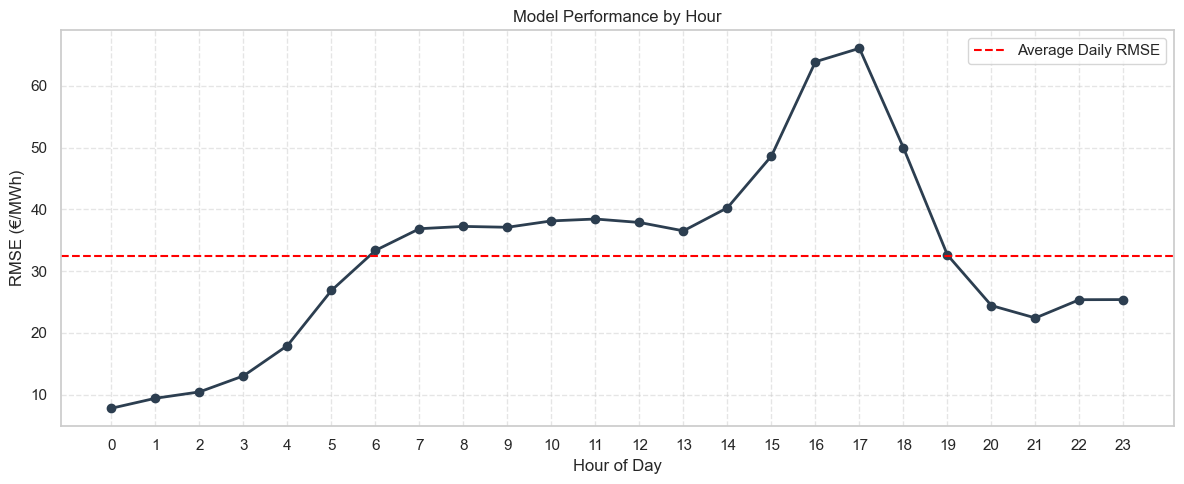

In [119]:
mse_per_hour = np.mean((y_daily_holdout.values - y_pred_daily)**2, axis=0)
rmse_per_hour = np.sqrt(mse_per_hour)

plt.figure(figsize=(12, 5))
plt.plot(range(24), rmse_per_hour, marker='o', linestyle='-', color='#2c3e50', linewidth=2)

# Add a reference line (e.g., mean RMSE)
plt.axhline(np.mean(rmse_per_hour), color='red', linestyle='--', label='Average Daily RMSE')

plt.title("Model Performance by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("RMSE (€/MWh)")
plt.xticks(range(24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("/Users/sam/Downloads/Model_Performance_by_Hour2.png", dpi=300)
plt.show()

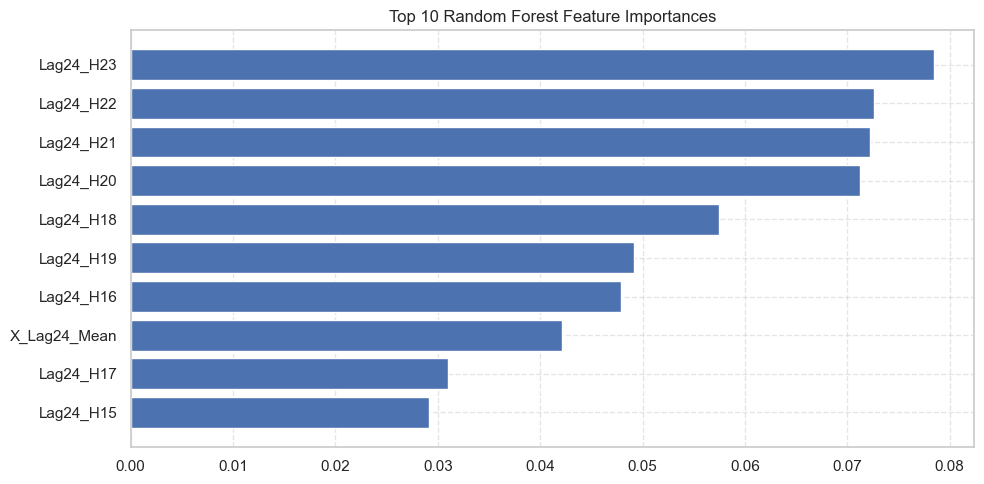

In [120]:
#for the random forest, this plot only makes limited sense... still good to have
all_importances = [est.feature_importances_ for est in multi_target_model.estimators_]
mean_importances = np.mean(all_importances, axis=0)

feature_imp = pd.DataFrame({
    "Feature": X_daily_train.columns,
    "Importance": mean_importances
}).sort_values(by="Importance", ascending=False)

top10_vec = feature_imp.head(10)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
plt.barh(top10_vec["Feature"], top10_vec["Importance"])
plt.title("Top 10 Random Forest Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
#plt.savefig("/Users/sam/Downloads/Feature Importance RF.png", dpi=300)
plt.show()

In [44]:
top_features_list = []
feature_names = X_daily_train.columns

for hour, model in enumerate(multi_target_model.estimators_):
    ims = model.feature_importances_
    top_idx = np.argmax(ims)
    top_features_list.append({
        'Hour' : hour,
        'Feature' : feature_names[top_idx],
        'Importance' : ims[top_idx]
    })

df_top_features = pd.DataFrame(top_features_list)

df_top_features

,Hour,Feature,Importance
0,0,Lag24_H23,0.987086
1,1,Lag24_H23,0.979643
2,2,Lag24_H23,0.939188
3,3,Lag24_H23,0.769061
4,4,Lag24_H23,0.427889
5,5,Lag24_H23,0.331915
6,6,Lag24_H23,0.488924
7,7,Lag24_H23,0.606908
8,8,Lag24_H23,0.614801
9,9,Lag24_H23,0.535229


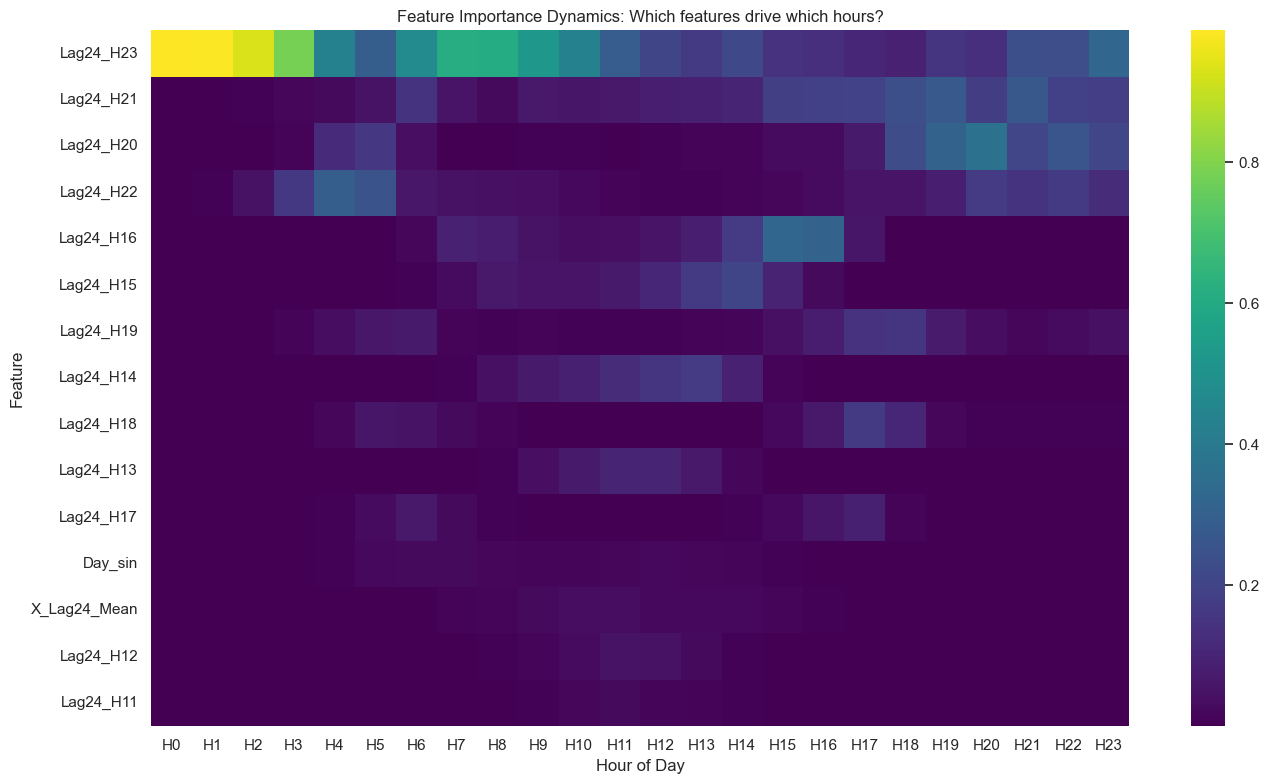

In [87]:
importance_matrix = np.array(all_importances).T

heatmap_df = pd.DataFrame(
    importance_matrix,
    index=X_daily_train.columns,
    columns=[f'H{h}' for h in range(24)]
)

# 2. Sort by "Total Importance" so the best features are at the top
heatmap_df['Total'] = heatmap_df.sum(axis=1)
heatmap_df = heatmap_df.sort_values('Total', ascending=False).drop(columns='Total')

# 3. Plot Top 15 Features as a Heatmap
plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_df.head(15), cmap="viridis", annot=False)
plt.title("Feature Importance Dynamics: Which features drive which hours?")
plt.xlabel("Hour of Day")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

### Multi Output Random Forest Regressor with Walk Forward Validation
___

The RF before did a training once (80%) and then a testing (20%) so we basically looked about 1.5years in the future without retraining, which is not directly what we need our model to be.
- However the Rolling Window approach from before is not that great for Random Forest.
- Expading Window would be the better approach

In [44]:
predictions = []
true_values = []

vector_prediction_model_folds = RandomForestRegressor(**best_params_n1, random_state=42, n_jobs= -1)
multi_target_model_fold = MultiOutputRegressor(verctor_prediction_model)

X_current_train = X_daily_train.copy()
y_current_train = y_daily_train.copy()

step_size = 7

for i in range(0, len(X_daily_holdout), step_size):

    multi_target_model_fold.fit(X_current_train, y_current_train.values)

    next_X = X_daily_holdout.iloc[i : i + step_size]
    next_y = y_daily_holdout.iloc[i : i + step_size]

    pred = multi_target_model_fold.predict(next_X)

    predictions.append(pred[0])
    true_values.append(next_y.values[0])

    X_current_train = pd.concat([X_current_train, next_X])
    y_current_train = pd.concat([y_current_train, next_y])

    print(f'Processed fold {i} out of {len(X_daily_holdout)}')

predictions = np.array(predictions)
true_values = np.array(true_values)


Processed fold 0 out of 517
Processed fold 7 out of 517
Processed fold 14 out of 517
Processed fold 21 out of 517
Processed fold 28 out of 517
Processed fold 35 out of 517
Processed fold 42 out of 517
Processed fold 49 out of 517
Processed fold 56 out of 517
Processed fold 63 out of 517
Processed fold 70 out of 517
Processed fold 77 out of 517
Processed fold 84 out of 517
Processed fold 91 out of 517
Processed fold 98 out of 517
Processed fold 105 out of 517
Processed fold 112 out of 517
Processed fold 119 out of 517
Processed fold 126 out of 517
Processed fold 133 out of 517
Processed fold 140 out of 517
Processed fold 147 out of 517
Processed fold 154 out of 517
Processed fold 161 out of 517
Processed fold 168 out of 517
Processed fold 175 out of 517
Processed fold 182 out of 517
Processed fold 189 out of 517
Processed fold 196 out of 517
Processed fold 203 out of 517
Processed fold 210 out of 517
Processed fold 217 out of 517
Processed fold 224 out of 517
Processed fold 231 out of 5

In [45]:
rmse_wf = np.sqrt(mean_squared_error(true_values, predictions))
mse_wf = mean_squared_error(true_values, predictions)
mae_wf = mean_absolute_error(true_values, predictions)

print("––– Walk-Forward Validation Results (retraining  –––")
print(f"MSE: {mse_wf:.2f}")
print(f"RMSE: {rmse_wf:.2f}")
print(f"MAE: {mae_wf:.2f}")

––– Walk-Forward Validation Results (retraining  –––
MSE: 1133.43
RMSE: 33.67
MAE: 21.43


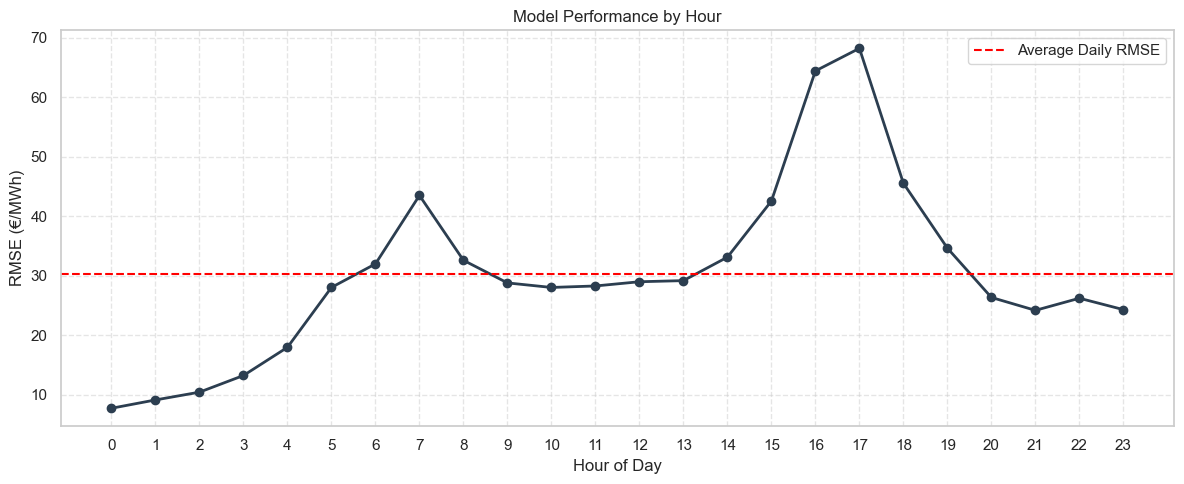

In [46]:
mse_per_hour = np.mean((true_values - predictions) ** 2, axis=0)
rmse_per_hour = np.sqrt(mse_per_hour)

plt.figure(figsize=(12, 5))
plt.plot(range(24), rmse_per_hour, marker='o', linestyle='-', color='#2c3e50', linewidth=2)

# Add a reference line (e.g., mean RMSE)
plt.axhline(np.mean(rmse_per_hour), color='red', linestyle='--', label='Average Daily RMSE')

plt.title("Model Performance by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("RMSE (€/MWh)")
plt.xticks(range(24))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("/Users/sam/Downloads/Model_Performance_by_Hour4.png", dpi=300)
plt.show()

### Random Forest Simple (old approach, hourly prediction)
___

Old approach, this is not that relevant

In [128]:
data_copy_rf = df_data_final.copy()

X_rf, y_rf, X_holdout, y_holdout = chronological_train_test_split_df(data_copy_rf, 'Price')

print('Training set shape:', X_rf.shape, y_rf.shape)
print('Holdout set shape:', X_holdout.shape, y_holdout.shape)

Training set shape: (49824, 48) (49824,)
Holdout set shape: (12449, 48) (12449,)


Trying to do many random forests trying to find the best parameters
- https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RandomizedSearchCV.html

In [129]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, 16, None],
    'min_samples_leaf': [4, 6, 10],
    'bootstrap': [True],
    'max_samples': [0.4, 0.6, 0.8],
    'max_features': ['sqrt']
}

random_forest_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_dist,
    scoring='neg_mean_squared_error',
    n_iter=10,
    cv=tscv,
    random_state=42,
    n_jobs=-1
)

random_forest_search.fit(X_rf, y_rf.values.ravel())

best_params = random_forest_search.best_params_
print("––– Best Parameters for a Random Forest –––")
print(best_params)

––– Best Parameters for a Random Forest –––
{'n_estimators': 300, 'min_samples_leaf': 4, 'max_samples': 0.8, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': True}


In [130]:
best_params = random_forest_search.best_params_

final_model = random_forest_search.best_estimator_

y_pred_holdout = final_model.predict(X_holdout)

rmse_final = np.sqrt(mean_squared_error(y_holdout, y_pred_holdout))
mae_final = mean_absolute_error(y_holdout, y_pred_holdout)
mse_final = mean_squared_error(y_holdout, y_pred_holdout)

print(f'––– Random Forest (Holdout) OLD!!–––')
print(f'MSE: {mse_final:.2f}, \nRMSE: {rmse_final:.2f}, \nMAE: {mae_final:.2f}')

––– Random Forest (Holdout) OLD!!–––
MSE: 1626.02, 
RMSE: 40.32, 
MAE: 25.80


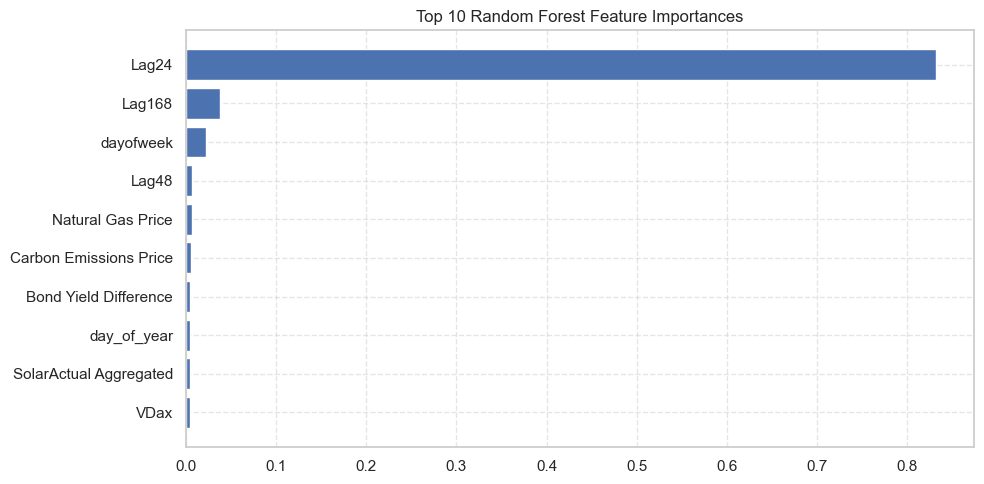

In [69]:
importances = final_model.feature_importances_
feature_imp = pd.DataFrame({
    "Feature": X_rf.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

top10 = feature_imp.head(10)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))
plt.barh(top10["Feature"], top10["Importance"])
plt.title("Top 10 Random Forest Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.grid(True, linestyle='--', alpha=0.5)
#plt.savefig("/Users/sam/Downloads/Feature Importance RF.png", dpi=300)
plt.show()
#our designated naive predictor

# Basic Battery Trader
___
Using the prediction of the random forest as a start

In [136]:
Battery_size = 1 #MWh
Battery_efficiency = 0.85
min_profit = 10
actuals = y_daily_holdout.copy() #change to the corresponding model (currently connected to the Multi Output Random Forest Regressor)
forecasts = pd.DataFrame(y_pred_daily, index=actuals.index, columns=actuals.columns)

actuals.index = pd.to_datetime(actuals.index)
forecasts.index = pd.to_datetime(forecasts.index)

portfolio = pd.DataFrame(index=np.unique(actuals.index.date))
portfolio['Daily_profit'] = 0
portfolio['Action'] = 'Hold'
portfolio['Buy_hour']= np.nan
portfolio['Sell_hour'] = np.nan

for day in portfolio.index:
    day_str = str(day)
    day_forecast = forecasts.loc[day_str].values
    day_actuals = actuals.loc[day_str].values

    buy_hour = np.argmin(day_forecast)
    buy_price = day_forecast[buy_hour]

    if buy_hour == 23:
        portfolio.loc[day, 'Action'] = 'Skip'
        continue

    potential_sell_prices = day_forecast[buy_hour + 1 : ]

    if len(potential_sell_prices) == 0:
        portfolio.loc[day, 'Action'] = 'Skip'
        continue

    sell_relative_idx = np.argmax(potential_sell_prices)
    sell_hour = buy_hour + 1 + sell_relative_idx
    sell_price = day_forecast[sell_hour]

    expected_spread = ((sell_price * Battery_efficiency) - buy_price)*Battery_size

    if expected_spread > min_profit:
        real_price_buy = day_actuals[buy_hour]
        real_price_sell = day_actuals[sell_hour]

        real_profit = ((real_price_sell * Battery_efficiency) - real_price_buy)*Battery_size
        portfolio.loc[day, 'Action'] = 'Trade'
        portfolio.loc[day, 'Buy_hour'] = buy_hour
        portfolio.loc[day, 'Sell_hour'] = sell_hour
        portfolio.loc[day, 'Daily_profit'] = real_profit

    else:
        portfolio.loc[day, 'Daily_Profit'] = 0.0
        portfolio.loc[day, 'Action'] = 'Skip'

portfolio

/var/folders/hr/rcbnj_fs4pd2b0zkz9ccr89m0000gn/T/ipykernel_13167/3014012482.py:48: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '136.9475' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  portfolio.loc[day, 'Daily_profit'] = real_profit


,Daily_profit,Action,Buy_hour,Sell_hour,Daily_Profit
2024-06-16,136.947500,Trade,12.0,18.0,NaN
2024-06-17,132.016000,Trade,12.0,18.0,NaN
2024-06-18,89.049500,Trade,12.0,18.0,NaN
2024-06-19,99.701000,Trade,12.0,18.0,NaN
2024-06-20,116.266500,Trade,11.0,18.0,NaN
...,...,...,...,...,...
2025-11-11,0.000000,Skip,NaN,NaN,NaN
2025-11-12,33.675750,Trade,1.0,16.0,NaN
2025-11-13,104.252125,Trade,2.0,17.0,NaN
2025-11-14,-3.584000,Trade,12.0,17.0,NaN


In [137]:
print(portfolio.head())
print(portfolio.tail())
Total_profit = portfolio['Daily_profit'].sum()
print(f'\n––– Total Profit –––\n{Total_profit}')

            Daily_profit Action  Buy_hour  Sell_hour  Daily_Profit
2024-06-16      136.9475  Trade      12.0       18.0           NaN
2024-06-17      132.0160  Trade      12.0       18.0           NaN
2024-06-18       89.0495  Trade      12.0       18.0           NaN
2024-06-19       99.7010  Trade      12.0       18.0           NaN
2024-06-20      116.2665  Trade      11.0       18.0           NaN
            Daily_profit Action  Buy_hour  Sell_hour  Daily_Profit
2025-11-11      0.000000   Skip       NaN        NaN           NaN
2025-11-12     33.675750  Trade       1.0       16.0           NaN
2025-11-13    104.252125  Trade       2.0       17.0           NaN
2025-11-14     -3.584000  Trade      12.0       17.0           NaN
2025-11-15     30.264125  Trade       2.0       17.0           NaN

––– Total Profit –––
45054.70775


### Battery Energy Storage System (BESS)

---

- https://docs.nrel.gov/docs/fy25osti/93281.pdf
- https://www.ritarpower.com/industry_information/1MWh-Battery-Energy-Storage-System-Prices_421.html
- https://energetechsolar.com/1mwh-1036v-1050ah-battery-energy-storage-system

We can roughly estimate that it would cost us about 430'000$, so around 370'000EUR to set up the battery

# Appendix
___
- API calls from ENTSO-E and Open-Meteo

### Entso-E – API Call

- https://transparency.entsoe.eu

In [ ]:
api_key = "key" #takes a long time to run

client = EntsoePandasClient(api_key=api_key)

start = pd.Timestamp('2015-11-17', tz='Europe/Berlin')
end = pd.Timestamp('2025-11-17', tz='Europe/Berlin')
country_code = 'DE_LU' #country_code = 'DE_AT_LU' for before 2018-10-01

generation_act = client.query_generation(country_code, start=start, end=end)

In [ ]:
generation_act.rename(columns={'Unnamed: 0_level_0': 'Date', 'Unnamed: 0_level_1' : 'Date'}, inplace=True)
generation_act.columns = [''.join([str(c) for c in col if str(c) != 'nan']).strip()
              for col in generation_act.columns]
generation_act['DateDate'] = pd.to_datetime(generation_act['DateDate'], utc=True)
df_clean = generation_act.set_index('DateDate').sort_index()
df_hourly = df_clean.resample('h').mean() #because it was 15min before

### Open Meteo – API Call

- https://open-meteo.com/en/docs/historical-weather-api

In [ ]:
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

German_states = {
    "Schleswig_Holstein": {"lat": 54.2, "lon": 9.6, "region": "North"},
    "Niedersachsen":      {"lat": 52.6, "lon": 9.7, "region": "North"},
    "Mecklenburg_Vorp":   {"lat": 53.6, "lon": 12.4, "region": "North"},
    "Hamburg":            {"lat": 53.5, "lon": 10.0, "region": "North"},
    "Bremen":             {"lat": 53.1, "lon": 8.8,  "region": "North"},

    "Bayern":             {"lat": 48.8, "lon": 11.4, "region": "South"},
    "Baden_Wuerttemberg": {"lat": 48.5, "lon": 9.0,  "region": "South"},
    "NRW":                {"lat": 51.5, "lon": 7.5,  "region": "West"},
    "Rheinland_Pfalz":    {"lat": 49.9, "lon": 7.4,  "region": "West"},
    "Saarland":           {"lat": 49.4, "lon": 6.9,  "region": "West"},
    "Hessen":             {"lat": 50.6, "lon": 9.0,  "region": "West"},

    "Brandenburg":        {"lat": 52.1, "lon": 13.5, "region": "East"},
    "Sachsen":            {"lat": 51.0, "lon": 13.3, "region": "East"},
    "Sachsen_Anhalt":     {"lat": 51.9, "lon": 11.5, "region": "East"},
    "Thueringen":         {"lat": 50.9, "lon": 11.0, "region": "East"},
    "Berlin":             {"lat": 52.5, "lon": 13.4, "region": "East"},
}

url = "https://archive-api.open-meteo.com/v1/archive"

In [ ]:
def German_state_weather(state, lat, lon):
    params = {
        'latitude': lat,
        'longitude': lon,
        'start_date': '2018-09-01', #increase later – have it that time for the beginning
        'end_date': '2025-11-23',
        'hourly': ['temperature_2m', 'wind_speed_100m', 'cloud_cover', 'precipitation']
    }
    print(f'––– State –––\n{state}\n')
    responses = openmeteo.weather_api(url, params=params)
    response = responses[0]

    hourly = response.Hourly()

    hourly_data = pd.date_range(
        start = pd.to_datetime(hourly.Time(), unit = 's', utc = True),
        end =  pd.to_datetime(hourly.TimeEnd(), unit = 's', utc = True),
        freq = pd.Timedelta(seconds = hourly.Interval()),
        inclusive = 'left'
    )

    data = {
        'Timestamp': hourly_data,
        f'{state}_Temp': hourly.Variables(0).ValuesAsNumpy(),
        f'{state}_Wind': hourly.Variables(1).ValuesAsNumpy(),
        f'{state}_Cloud': hourly.Variables(2).ValuesAsNumpy(),
        f'{state}_Precip': hourly.Variables(3).ValuesAsNumpy(),
    }

    return pd.DataFrame(data).set_index('Timestamp')

In [ ]:
state_all =[]

for states, values in German_states.items():
    df_state = German_state_weather(states, values['lat'], values['lon'])
    state_all.append(df_state)
    time.sleep(15)

final_weather_df = pd.concat(state_all, axis = 1)